In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Vertical velocity from PIV analysis
## Made from `/PIV/plate_top_rectangular_IR/...`
* IR: 16 x 32 px
* Overlap = 50%
* SA = 16 x 32 px
* stepsize = 3, 5, 7
* sig2noise threshold = 1.2
* max_iter = 10
* kernel_size = 2

In [129]:
base_path = '/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/'
# Results from PIV processing
# 16 x 32 window size, dt = 3, 5, 7 frames, respectively for the three amplitudes
piv_a03_r1 = xr.open_dataset(base_path + 'f14a03_rec_res_r1.nc')
piv_a03_r2 = xr.open_dataset(base_path + 'f14a03_rec_res_r2.nc')
piv_a03_r3 = xr.open_dataset(base_path + 'f14a03_rec_res_r3.nc')

piv_a02_r1 = xr.open_dataset(base_path + 'f14a02_rec_res_r1.nc')
piv_a02_r2 = xr.open_dataset(base_path + 'f14a02_rec_res_r2.nc')
piv_a02_r3 = xr.open_dataset(base_path + 'f14a02_rec_res_r3.nc')

piv_a01_r1 = xr.open_dataset(base_path + 'f14a01_rec_res_r1.nc')
piv_a01_r2 = xr.open_dataset(base_path + 'f14a01_rec_res_r2.nc')
piv_a01_r3 = xr.open_dataset(base_path + 'f14a01_rec_res_r3.nc')

base_path = '/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/'
# Results from probe analysis
no_plates_20 = pd.read_csv(base_path + 'no_plates_20cm.csv')
plates_20 = pd.read_csv(base_path + 'plates_20cm.csv')

f14a03 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.3)]
f14a02 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.2)]
f14a01 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.1)]

f14a03_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.3)]
f14a02_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.2)]
f14a01_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.1)]

del no_plates_20, plates_20

## Observed values

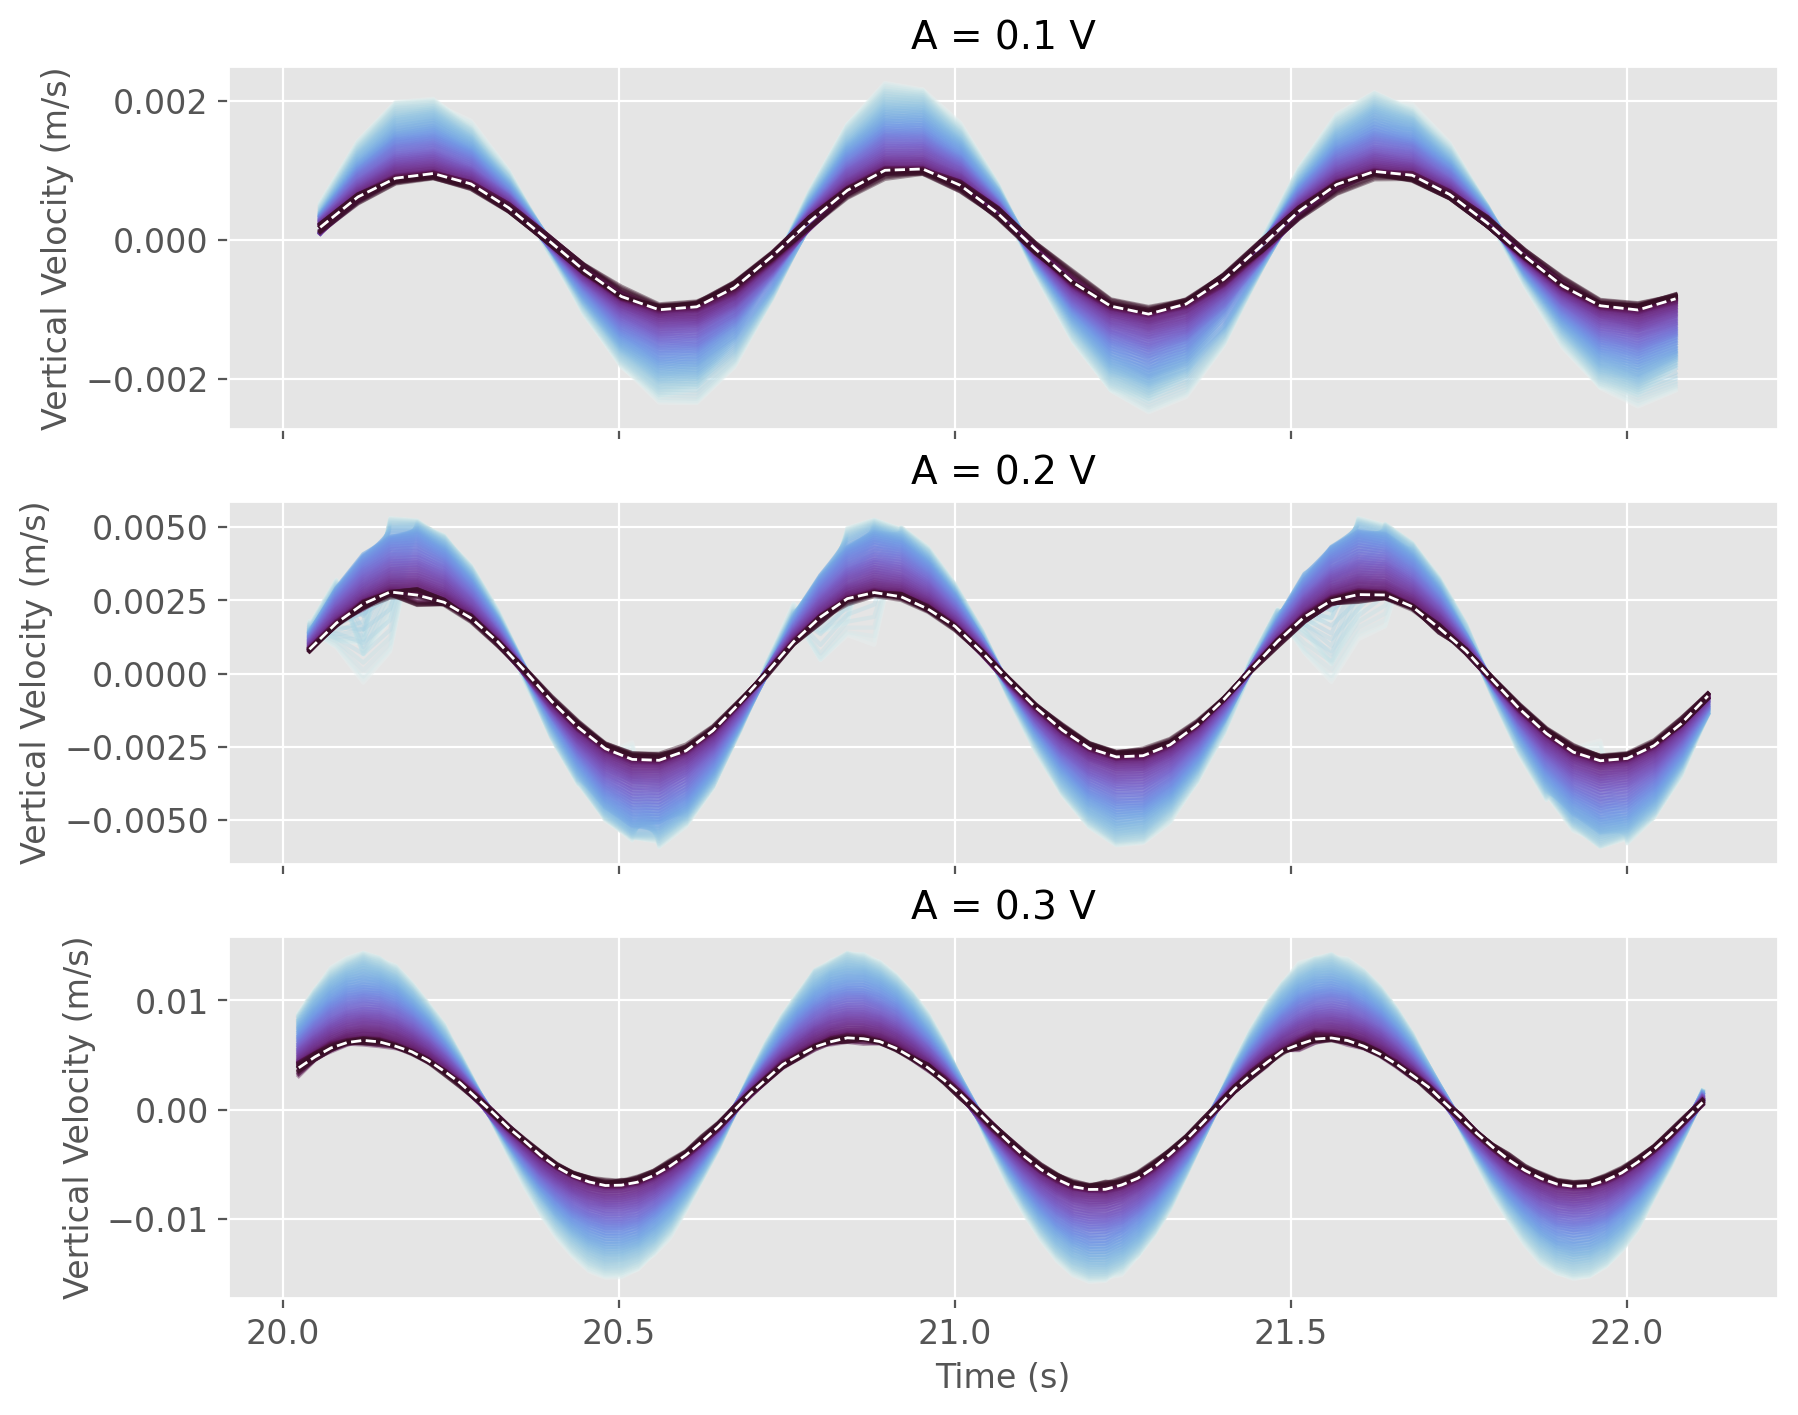

In [130]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# choose a colormap
cmap = cmo.dense
N = 50  # number of lines per subplot

for i in range(N):
    # normalize i to [0, 1] to sample from the colormap
    t = i / (N - 1)
    color = cmap(t)

    # A = 0.1 V
    ax[0].plot(piv_a01_r1.time, piv_a01_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r2.time, piv_a01_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r3.time, piv_a01_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.2 V
    ax[1].plot(piv_a02_r1.time, piv_a02_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r2.time, piv_a02_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r3.time, piv_a02_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.3 V
    ax[2].plot(piv_a03_r1.time, piv_a03_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r2.time, piv_a03_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r3.time, piv_a03_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    
a01_mean = np.mean([piv_a01_r1['w'].mean(axis=2)[:, 42], piv_a01_r2['w'].mean(axis=2)[:, 42], piv_a01_r3['w'].mean(axis=2)[:, 42]], axis=0)
a02_mean = np.mean([piv_a02_r1['w'].mean(axis=2)[:, 42], piv_a02_r2['w'].mean(axis=2)[:, 42], piv_a02_r3['w'].mean(axis=2)[:, 42]], axis=0)
a03_mean = np.mean([piv_a03_r1['w'].mean(axis=2)[:, 42], piv_a03_r2['w'].mean(axis=2)[:, 42], piv_a03_r3['w'].mean(axis=2)[:, 42]], axis=0)

ax[0].plot(piv_a01_r1.time, a01_mean, color='white', linestyle='--', linewidth=1, label='Mean')
ax[1].plot(piv_a02_r1.time, a02_mean, color='white', linestyle='--', linewidth=1, label='Mean')
ax[2].plot(piv_a03_r1.time, a03_mean, color='white', linestyle='--', linewidth=1, label='Mean')

ax[0].set_title('A = 0.1 V')
ax[1].set_title('A = 0.2 V')
ax[2].set_title('A = 0.3 V')
ax[2].set_xlabel('Time (s)')

for a in ax:
    a.set_ylabel('Vertical Velocity (m/s)')

## The theoretical values

In [131]:
start = piv_a03_r1.time.values[0]
end = piv_a03_r1.time.values[-1]
time_piv = piv_a03_r1.time.values

In [132]:
f = 1.4  # frequency (Hz)
omega = 2 * np.pi * f  # angular frequency (rad/s)
g = 9.81  # gravitational acceleration (m/s^2)
nu = 1e-6  # kinematic viscosity of water (m^2/s)
D = 0.2  # water height (m)
H = 0.15  # depth of plate top (m)
h = 0.01  # distance between plates (m)
k = wave_number_in_theory(f, H)

a_theory, a_weber = spatial_damping_coefficient(k, D, H, h)

In [133]:
A01 = np.mean([np.mean(f14a01['amp_P1']), np.mean(f14a01_p['amp_P1'])])
A02 = np.mean([np.mean(f14a02['amp_P1']), np.mean(f14a02_p['amp_P1'])])
A03 = np.mean([np.mean(f14a03['amp_P1']), np.mean(f14a03_p['amp_P1'])])

In [134]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])

In [135]:
# Start of "wave"
# Distance x from second probe to end of PIV frame
x = 8.26 - x_probe_pos[1]

In [136]:
# Airy theory velocity at z = -H
u_airy_a03 = u_airy(A03, f, k, D, H, x, time_piv)
u_airy_a02 = u_airy(A02, f, k, D, H, x, time_piv)
u_airy_a01 = u_airy(A01, f, k, D, H, x, time_piv)

w_airy_a03 = w_airy(A03, f, k, D, H, x, time_piv)
w_airy_a02 = w_airy(A02, f, k, D, H, x, time_piv)
w_airy_a01 = w_airy(A01, f, k, D, H, x, time_piv)

In [137]:
# Weber theory velocity at z = -H
w_theory_a03 = vertical_velocity(A03, D, H, f, a_theory, k, h, x, time_piv)
w_theory_a02 = vertical_velocity(A02, D, H, f, a_theory, k, h, x, time_piv)
w_theory_a01 = vertical_velocity(A01, D, H, f, a_theory, k, h, x, time_piv)

In [138]:
#w_theory2_a03 = vertical_velocity_2(A03, D, H, f, a_theory, k, h, x, time_piv)
#w_theory2_a02 = vertical_velocity_2(A02, D, H, f, a_theory, k, h, x, time_piv)
#w_theory2_a01 = vertical_velocity_2(A01, D, H, f, a_theory, k, h, x, time_piv)

In [139]:
def vertical_velocity3(A, D, H, f, a, k, h, x, t):
    """
    Calculate the real vertical velocity
    at the top of the plates (z=-H).
    
    Corresponds to the real part of the modified version 
    of Equation 35 in Weber (2025).

    Parameters:
        A : Wave amplitude (m)
        D : total water depth (m)
        H : depth of plate top (m)
        f : wave frequency (Hz)
        a : spatial damping coefficient (1/m)
        k : wavenumber (1/m)
        h : plate spacing (m)
        x: horizontal position (m)
        t: time (s)

    Returns:
        w : average vertical velocity (m/s)
    """

    # Constants
    g = 9.81  # gravitational acceleration (m/s^2)
    nu = 1e-6  # kinematic viscosity of water (m^2/s)

    # Angular frequency
    omega = 2 * np.pi * f

    # Phase
    theta = k*x - omega*t - 2.5

    term1 = 2*(g*H)**0.5 * A * np.exp(-a*x) * a
    term2 = (((omega*h**2*D)/(12**2*H*nu))*np.sin(theta) - np.cos(theta))
    w = term1 * term2
    return w

In [140]:
w_theory3_a03 = vertical_velocity3(A03, D, H, f, a_theory, k, h, x, time_piv)
w_theory3_a02 = vertical_velocity3(A02, D, H, f, a_theory, k, h, x, time_piv)
w_theory3_a01 = vertical_velocity3(A01, D, H, f, a_theory, k, h, x, time_piv)

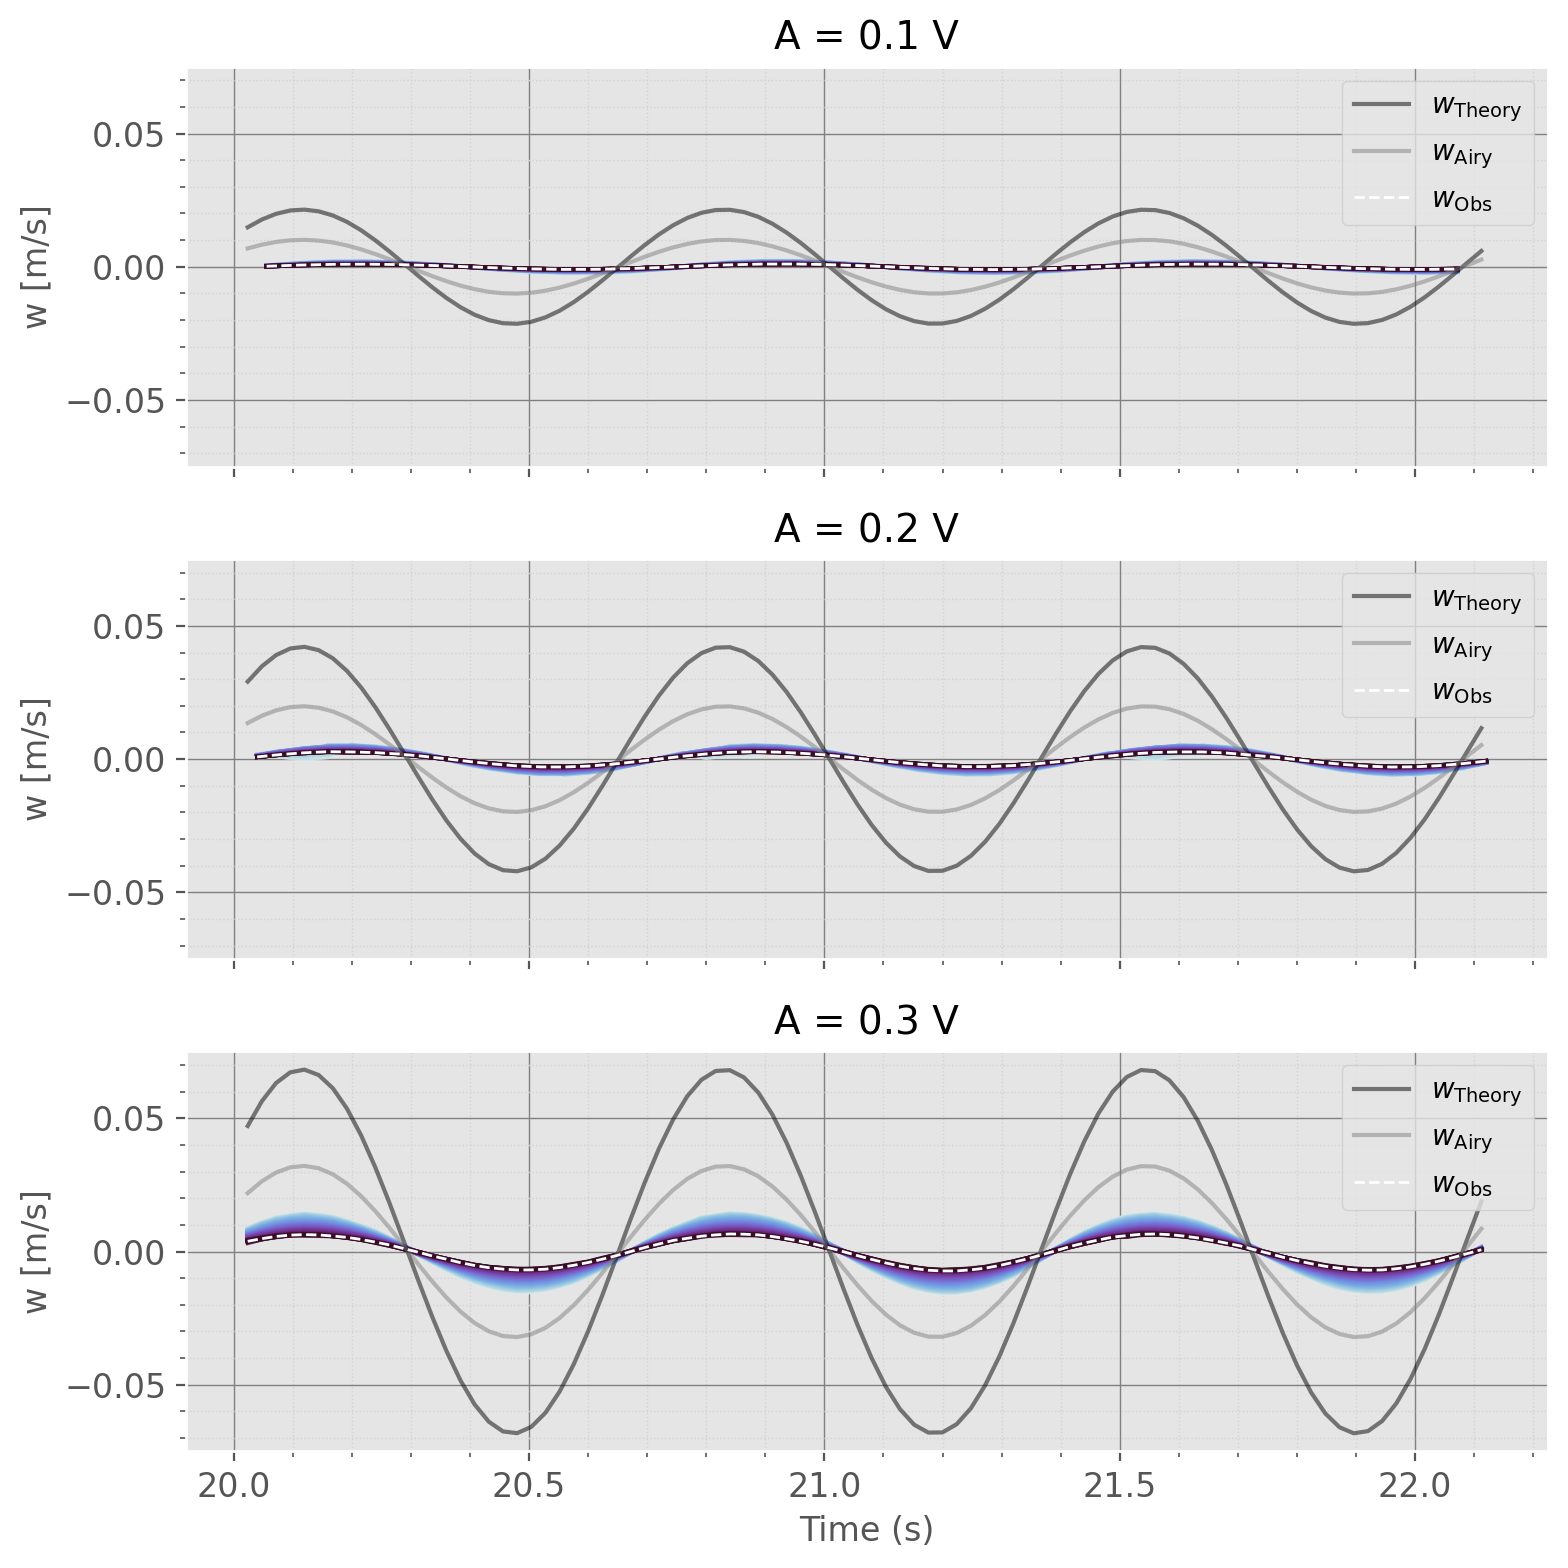

In [141]:
fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharey=True, sharex=True)

# choose a colormap
cmap = cmo.dense
N = 50  # number of lines per subplot

for i in range(N):
    # normalize i to [0, 1] to sample from the colormap
    t = i / (N - 1)
    color = cmap(t)

    # A = 0.1 V
    ax[0].plot(piv_a01_r1.time, piv_a01_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r2.time, piv_a01_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r3.time, piv_a01_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.2 V
    ax[1].plot(piv_a02_r1.time, piv_a02_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r2.time, piv_a02_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r3.time, piv_a02_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.3 V
    ax[2].plot(piv_a03_r1.time, piv_a03_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r2.time, piv_a03_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r3.time, piv_a03_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    
    
a01_mean = np.mean([piv_a01_r1['w'].mean(axis=2)[:, 42], piv_a01_r2['w'].mean(axis=2)[:, 42], piv_a01_r3['w'].mean(axis=2)[:, 42]], axis=0)
a02_mean = np.mean([piv_a02_r1['w'].mean(axis=2)[:, 42], piv_a02_r2['w'].mean(axis=2)[:, 42], piv_a02_r3['w'].mean(axis=2)[:, 42]], axis=0)
a03_mean = np.mean([piv_a03_r1['w'].mean(axis=2)[:, 42], piv_a03_r2['w'].mean(axis=2)[:, 42], piv_a03_r3['w'].mean(axis=2)[:, 42]], axis=0)

ax[0].plot(time_piv, w_theory_a01, color='black', alpha=0.5, label=r'${w}_{\text{Theory}}$')
ax[1].plot(time_piv, w_theory_a02, color='black', alpha=0.5, label=r'${w}_{\text{Theory}}$')
ax[2].plot(time_piv, w_theory_a03, color='black', alpha=0.5, label=r'${w}_{\text{Theory}}$')

ax[0].plot(time_piv, w_airy_a01, color='gray', alpha=0.5, label=r'${w}_{\text{Airy}}$')
ax[1].plot(time_piv, w_airy_a02, color='gray', alpha=0.5, label=r'${w}_{\text{Airy}}$')
ax[2].plot(time_piv, w_airy_a03, color='gray', alpha=0.5, label=r'${w}_{\text{Airy}}$')

ax[0].plot(piv_a01_r1.time, a01_mean, color='white', linestyle='--', linewidth=1, label=r'${w}_{\text{Obs}}$')
ax[1].plot(piv_a02_r1.time, a02_mean, color='white', linestyle='--', linewidth=1, label=r'${w}_{\text{Obs}}$')
ax[2].plot(piv_a03_r1.time, a03_mean, color='white', linestyle='--', linewidth=1, label=r'${w}_{\text{Obs}}$')

ax[0].set_title('A = 0.1 V')
ax[1].set_title('A = 0.2 V')
ax[2].set_title('A = 0.3 V')
ax[2].set_xlabel('Time (s)')

for a in ax:
    a.set_ylabel('w [m/s]')
    a.legend(ncol=1, loc='upper right', fontsize=10)
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/vertical_velocity_obs_vs_theory.png", dpi=300)

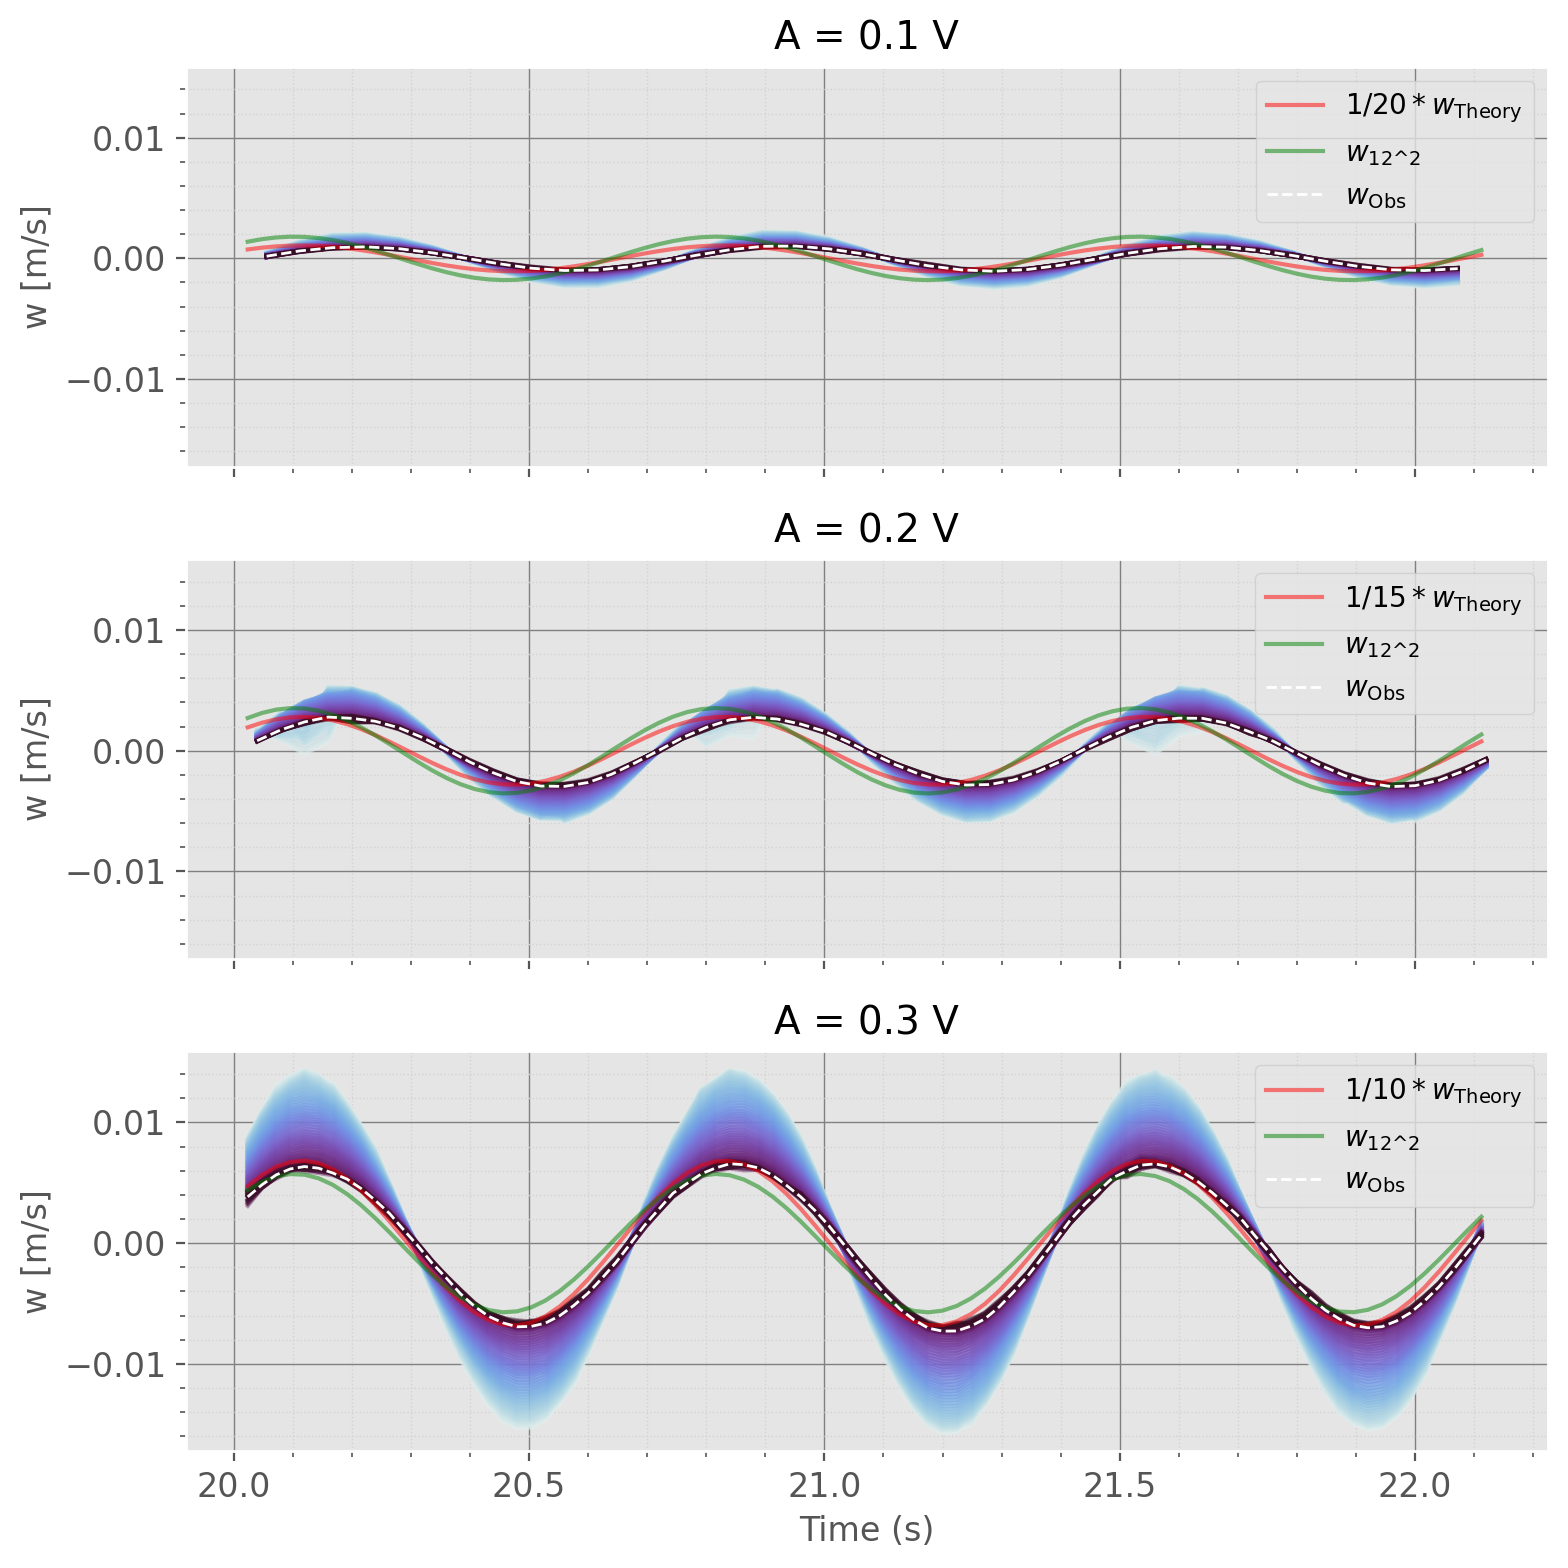

In [142]:
fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharey=True, sharex=True)

# choose a colormap
cmap = cmo.dense
N = 50  # number of lines per subplot

for i in range(N):
    # normalize i to [0, 1] to sample from the colormap
    t = i / (N - 1)
    color = cmap(t)

    # A = 0.1 V
    ax[0].plot(piv_a01_r1.time, piv_a01_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r2.time, piv_a01_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r3.time, piv_a01_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.2 V
    ax[1].plot(piv_a02_r1.time, piv_a02_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r2.time, piv_a02_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r3.time, piv_a02_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.3 V
    ax[2].plot(piv_a03_r1.time, piv_a03_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r2.time, piv_a03_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r3.time, piv_a03_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    
    
a01_mean = np.mean([piv_a01_r1['w'].mean(axis=2)[:, 42], piv_a01_r2['w'].mean(axis=2)[:, 42], piv_a01_r3['w'].mean(axis=2)[:, 42]], axis=0)
a02_mean = np.mean([piv_a02_r1['w'].mean(axis=2)[:, 42], piv_a02_r2['w'].mean(axis=2)[:, 42], piv_a02_r3['w'].mean(axis=2)[:, 42]], axis=0)
a03_mean = np.mean([piv_a03_r1['w'].mean(axis=2)[:, 42], piv_a03_r2['w'].mean(axis=2)[:, 42], piv_a03_r3['w'].mean(axis=2)[:, 42]], axis=0)

ax[0].plot(time_piv, (1/20) * w_theory_a01, color='red', alpha=0.5, label=r'$1/20 * {w}_{\text{Theory}}$')
ax[1].plot(time_piv, (1/15) * w_theory_a02, color='red', alpha=0.5, label=r'$1/15 * {w}_{\text{Theory}}$')
ax[2].plot(time_piv, (1/10) * w_theory_a03, color='red', alpha=0.5, label=r'$1/10 * {w}_{\text{Theory}}$')

ax[0].plot(time_piv, w_theory3_a01, color='green', alpha=0.5, label=r'${w}_{\text{12^2}}$')
ax[1].plot(time_piv, w_theory3_a02, color='green', alpha=0.5, label=r'${w}_{\text{12^2}}$')
ax[2].plot(time_piv, w_theory3_a03, color='green', alpha=0.5, label=r'${w}_{\text{12^2}}$')

ax[0].plot(piv_a01_r1.time, a01_mean, color='white', linestyle='--', linewidth=1, label=r'${w}_{\text{Obs}}$')
ax[1].plot(piv_a02_r1.time, a02_mean, color='white', linestyle='--', linewidth=1, label=r'${w}_{\text{Obs}}$')
ax[2].plot(piv_a03_r1.time, a03_mean, color='white', linestyle='--', linewidth=1, label=r'${w}_{\text{Obs}}$')

ax[0].set_title('A = 0.1 V')
ax[1].set_title('A = 0.2 V')
ax[2].set_title('A = 0.3 V')
ax[2].set_xlabel('Time (s)')

for a in ax:
    a.set_ylabel('w [m/s]')
    a.legend(ncol=1, loc='upper right', fontsize=10)
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/vertical_velocity_obs_vs_modified_theory.png", dpi=300)

In [143]:
max_a03 = np.max(a03_mean)
max_a02 = np.max(a02_mean)
max_a01 = np.max(a01_mean)

max_theory_a03 = np.max(w_theory_a03)
max_theory_a02 = np.max(w_theory_a02)
max_theory_a01 = np.max(w_theory_a01)

In [144]:
# Differences
diff_a03 = max_theory_a03/max_a03
diff_a02 = max_theory_a02/max_a02
diff_a01 = max_theory_a01/max_a01

print("The theoretical maximum vertical velocity is approximately {:.2f} times the observed maximum for A = 0.1 V.".format(diff_a01))
print("The theoretical maximum vertical velocity is approximately {:.2f} times the observed maximum for A = 0.2 V.".format(diff_a02))
print("The theoretical maximum vertical velocity is approximately {:.2f} times the observed maximum for A = 0.3 V.".format(diff_a03))

The theoretical maximum vertical velocity is approximately 21.02 times the observed maximum for A = 0.1 V.
The theoretical maximum vertical velocity is approximately 15.10 times the observed maximum for A = 0.2 V.
The theoretical maximum vertical velocity is approximately 10.38 times the observed maximum for A = 0.3 V.


In [145]:
piv_a01_r1.z

<xarray.DataArray 'z' (z: 50)> Size: 400B
array([0.001363, 0.002726, 0.004089, 0.005452, 0.006815, 0.008178, 0.009542,
       0.010905, 0.012268, 0.013631, 0.014994, 0.016357, 0.01772 , 0.019083,
       0.020446, 0.021809, 0.023172, 0.024535, 0.025899, 0.027262, 0.028625,
       0.029988, 0.031351, 0.032714, 0.034077, 0.03544 , 0.036803, 0.038166,
       0.039529, 0.040892, 0.042256, 0.043619, 0.044982, 0.046345, 0.047708,
       0.049071, 0.050434, 0.051797, 0.05316 , 0.054523, 0.055886, 0.057249,
       0.058613, 0.059976, 0.061339, 0.062702, 0.064065, 0.065428, 0.066791,
       0.068154])
Coordinates:
  * z        (z) float64 400B 0.001363 0.002726 0.004089 ... 0.06679 0.06815

In [146]:
def depth_formatter(y_tick, pos):
        # depth: negative downward
        # Adding ashift the depth values so that it matches real water depth
        return f"{-(y_tick + 0.09):.2f}"

In [147]:
z

array([0.00136308, 0.00272617, 0.00408925, 0.00545233, 0.00681542,
       0.0081785 , 0.00954158, 0.01090467, 0.01226775, 0.01363083,
       0.01499391, 0.016357  , 0.01772008, 0.01908316, 0.02044625,
       0.02180933, 0.02317241, 0.0245355 , 0.02589858, 0.02726166,
       0.02862475, 0.02998783, 0.03135091, 0.032714  , 0.03407708,
       0.03544016, 0.03680325, 0.03816633, 0.03952941, 0.04089249,
       0.04225558, 0.04361866, 0.04498174, 0.04634483, 0.04770791,
       0.04907099, 0.05043408, 0.05179716, 0.05316024, 0.05452333,
       0.05588641, 0.05724949, 0.05861258, 0.05997566, 0.06133874,
       0.06270183, 0.06406491, 0.06542799, 0.06679108, 0.06815416])

In [148]:
q = piv_a01_r1['u'][0, :, :]
q.size

3800

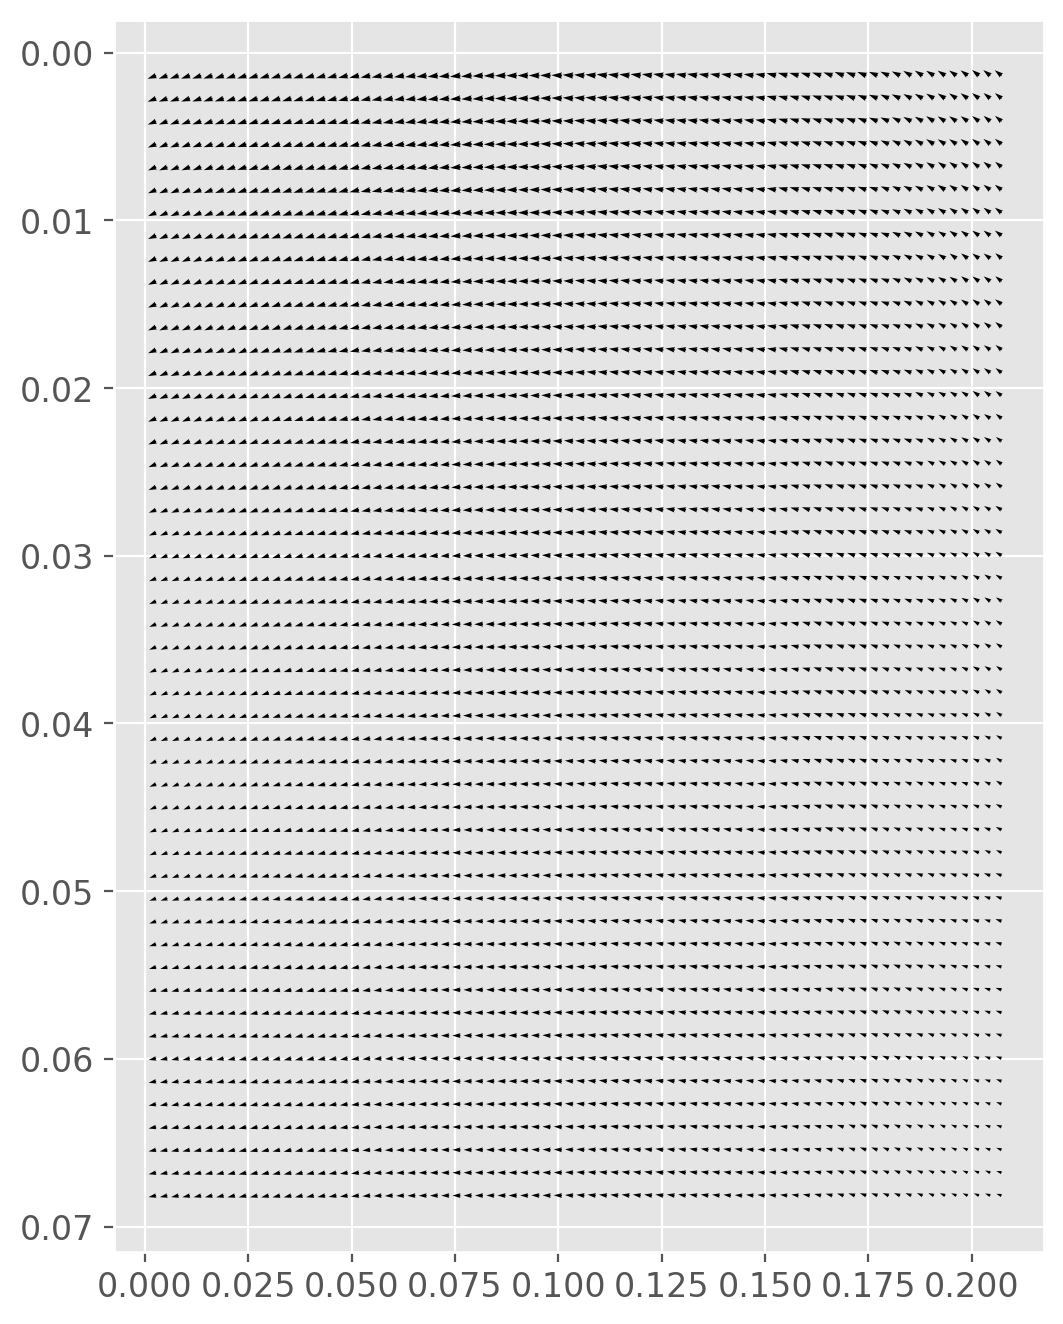

In [149]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.quiver(piv_a01_r1.x, piv_a01_r1.z, piv_a01_r1['u'][0, :, :], piv_a01_r1['w'][0, :, :])
ax.invert_yaxis()

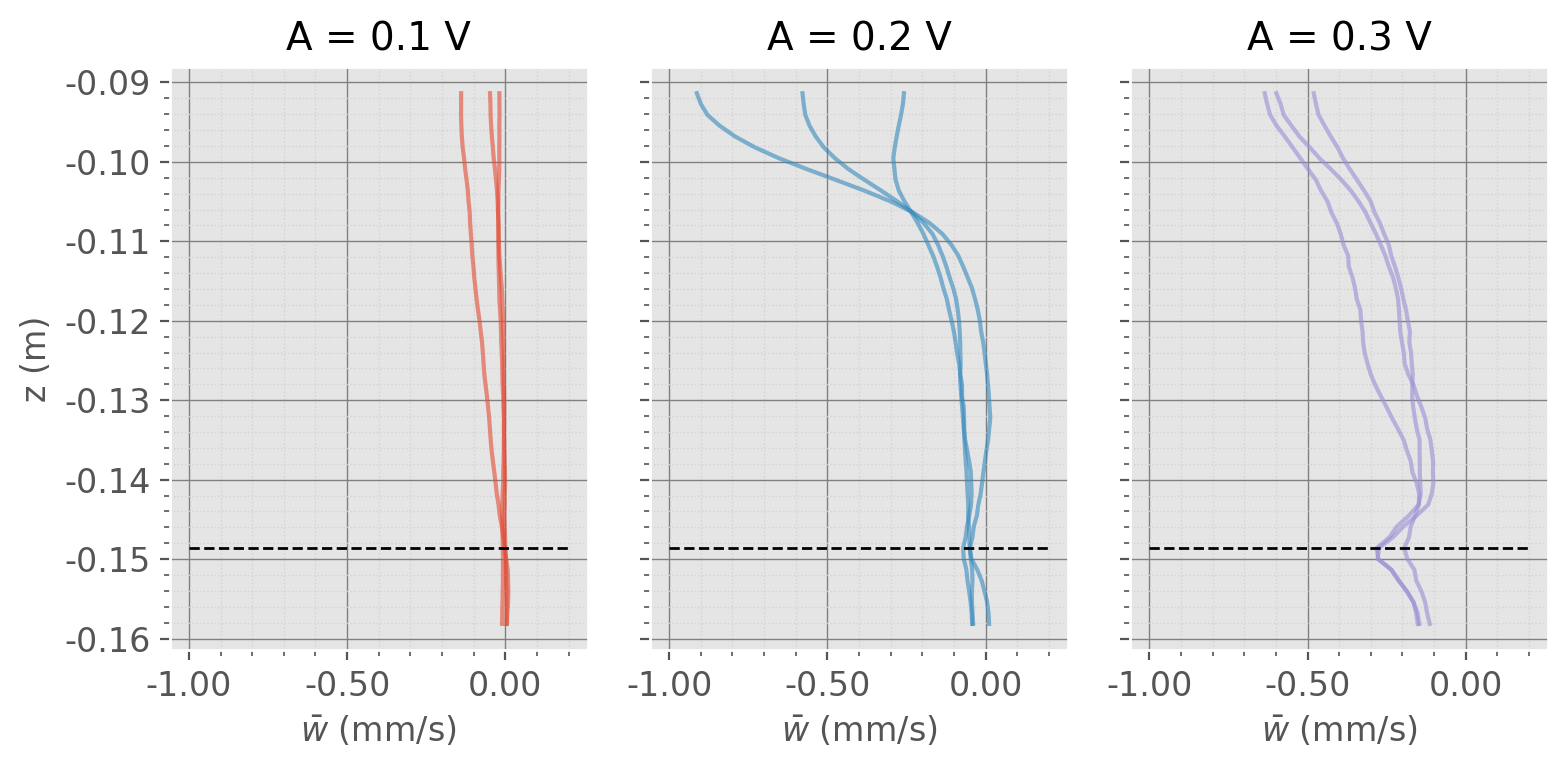

In [150]:
from matplotlib.ticker import FuncFormatter

def depth_formatter(y_tick, pos):
        # depth: negative downward
        # Adding ashift the depth values so that it matches real water depth
        return f"{-(y_tick + 0.09):.2f}"

fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=True)
z=piv_a01_r1.z.values

ax[0].plot(piv_a01_r1.w.mean(axis=(0, 2))*1000, z, color='C0', alpha=0.6, label='A = 0.1 V')
ax[0].plot(piv_a01_r2.w.mean(axis=(0, 2))*1000, z, color='C0', alpha=0.6)
ax[0].plot(piv_a01_r3.w.mean(axis=(0, 2))*1000, z, color='C0', alpha=0.6)

ax[1].plot(piv_a02_r1.w.mean(axis=(0, 2))*1000, z, color='C1', alpha=0.6, label='A = 0.2 V')
ax[1].plot(piv_a02_r2.w.mean(axis=(0, 2))*1000, z, color='C1', alpha=0.6)
ax[1].plot(piv_a02_r3.w.mean(axis=(0, 2))*1000, z, color='C1', alpha=0.6)

ax[2].plot(piv_a03_r1.w.mean(axis=(0, 2))*1000, z, color='C2', alpha=0.6, label='A = 0.3 V')
ax[2].plot(piv_a03_r2.w.mean(axis=(0, 2))*1000, z, color='C2', alpha=0.6)
ax[2].plot(piv_a03_r3.w.mean(axis=(0, 2))*1000, z, color='C2', alpha=0.6)

ax[0].set_ylabel('z (m)')
ax[0].set_title('A = 0.1 V')
ax[1].set_title('A = 0.2 V')
ax[2].set_title('A = 0.3 V')

for a in ax:
    a.invert_yaxis()
    a.set_xlabel(r'$\bar{w}$ (mm/s)')
    a.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    a.hlines(z[42], -1, 0.2, colors='black', linestyles='dashed', linewidth=1)
    a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')

plt.tight_layout()

In [151]:
u_a01_mean = np.mean([piv_a01_r1.u.mean(axis=(0, 2)), piv_a01_r2.u.mean(axis=(0, 2)), piv_a01_r3.u.mean(axis=(0, 2))], axis=0)
u_a02_mean = np.mean([piv_a02_r1.u.mean(axis=(0, 2)), piv_a02_r2.u.mean(axis=(0, 2)), piv_a02_r3.u.mean(axis=(0, 2))], axis=0)
u_a03_mean = np.mean([piv_a03_r1.u.mean(axis=(0, 2)), piv_a03_r2.u.mean(axis=(0, 2)), piv_a03_r3.u.mean(axis=(0, 2))], axis=0)

# Mean profiles
ax[1].plot(u_a01_mean*1000, z, color='C0', label='A = 0.1 V')
ax[1].plot(u_a02_mean*1000, z, color='C1', label='A = 0.2 V')
ax[1].plot(u_a03_mean*1000, z, color='C2', label='A = 0.3 V')

# Individual runs
ax[1].plot(piv_a01_r1.u.mean(axis=(0, 2))*1000, z, color='C0', linestyle='--', alpha=0.3)
ax[1].plot(piv_a01_r2.u.mean(axis=(0, 2))*1000, z, color='C0', linestyle='--', alpha=0.3)
ax[1].plot(piv_a01_r3.u.mean(axis=(0, 2))*1000, z, color='C0', linestyle='--', alpha=0.3)

ax[1].plot(piv_a02_r1.u.mean(axis=(0, 2))*1000, z, color='C1', linestyle='--', alpha=0.3)
ax[1].plot(piv_a02_r2.u.mean(axis=(0, 2))*1000, z, color='C1', linestyle='--', alpha=0.3)
ax[1].plot(piv_a02_r3.u.mean(axis=(0, 2))*1000, z, color='C1', linestyle='--', alpha=0.3)

ax[1].plot(piv_a03_r1.u.mean(axis=(0, 2))*1000, z, color='C2', linestyle='--', alpha=0.3)
ax[1].plot(piv_a03_r2.u.mean(axis=(0, 2))*1000, z, color='C2', linestyle='--', alpha=0.3)
ax[1].plot(piv_a03_r3.u.mean(axis=(0, 2))*1000, z, color='C2', linestyle='--', alpha=0.3)

ax[1].set_ylabel('z (m)')
ax[1].legend(fontsize=10, loc='center left')

ax[1].invert_yaxis()
ax[1].set_xlabel(r'$\bar{u}$ (mm/s)')
ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax[1].hlines(z[42], -1, 0.2, colors='black', linestyles='dashed', linewidth=1)
ax[1].yaxis.set_major_formatter(FuncFormatter(depth_formatter))
ax[1].minorticks_on()
ax[1].grid(which='major', linestyle='-', linewidth='0.5', color='gray')
ax[1].grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')

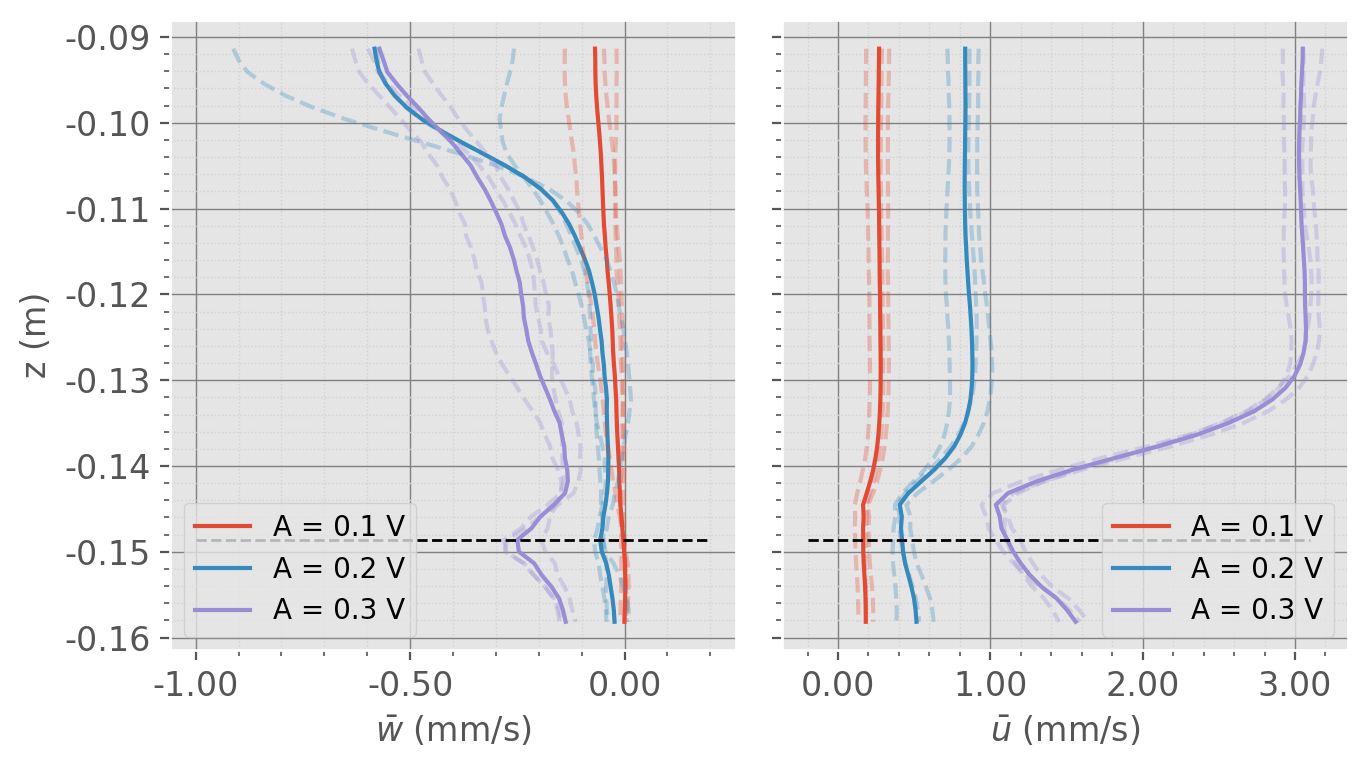

In [152]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4), sharey=True)
z = piv_a01_r1.z.values

w_a01_mean = np.mean([piv_a01_r1.w.mean(axis=(0, 2)), piv_a01_r2.w.mean(axis=(0, 2)), piv_a01_r3.w.mean(axis=(0, 2))], axis=0)
w_a02_mean = np.mean([piv_a02_r1.w.mean(axis=(0, 2)), piv_a02_r2.w.mean(axis=(0, 2)), piv_a02_r3.w.mean(axis=(0, 2))], axis=0)
w_a03_mean = np.mean([piv_a03_r1.w.mean(axis=(0, 2)), piv_a03_r2.w.mean(axis=(0, 2)), piv_a03_r3.w.mean(axis=(0, 2))], axis=0)

# Mean profiles
ax[0].plot(w_a01_mean*1000, z, color='C0', label='A = 0.1 V')
ax[0].plot(w_a02_mean*1000, z, color='C1', label='A = 0.2 V')
ax[0].plot(w_a03_mean*1000, z, color='C2', label='A = 0.3 V')

# Individual runs
ax[0].plot(piv_a01_r1.w.mean(axis=(0, 2))*1000, z, color='C0', linestyle='--', alpha=0.3)
ax[0].plot(piv_a01_r2.w.mean(axis=(0, 2))*1000, z, color='C0', linestyle='--', alpha=0.3)
ax[0].plot(piv_a01_r3.w.mean(axis=(0, 2))*1000, z, color='C0', linestyle='--', alpha=0.3)

ax[0].plot(piv_a02_r1.w.mean(axis=(0, 2))*1000, z, color='C1', linestyle='--', alpha=0.3)
ax[0].plot(piv_a02_r2.w.mean(axis=(0, 2))*1000, z, color='C1', linestyle='--', alpha=0.3)
ax[0].plot(piv_a02_r3.w.mean(axis=(0, 2))*1000, z, color='C1', linestyle='--', alpha=0.3)

ax[0].plot(piv_a03_r1.w.mean(axis=(0, 2))*1000, z, color='C2', linestyle='--', alpha=0.3)
ax[0].plot(piv_a03_r2.w.mean(axis=(0, 2))*1000, z, color='C2', linestyle='--', alpha=0.3)
ax[0].plot(piv_a03_r3.w.mean(axis=(0, 2))*1000, z, color='C2', linestyle='--', alpha=0.3)

ax[0].set_ylabel('z (m)')

ax[0].invert_yaxis()
ax[0].set_xlabel(r'$\bar{w}$ (mm/s)')
ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax[0].hlines(z[42], -1, 0.2, colors='black', linestyles='dashed', linewidth=1)
ax[0].yaxis.set_major_formatter(FuncFormatter(depth_formatter))
ax[0].minorticks_on()
ax[0].grid(which='major', linestyle='-', linewidth='0.5', color='gray')
ax[0].grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')

u_a01_mean = np.mean([piv_a01_r1.u.mean(axis=(0, 2)), piv_a01_r2.u.mean(axis=(0, 2)), piv_a01_r3.u.mean(axis=(0, 2))], axis=0)
u_a02_mean = np.mean([piv_a02_r1.u.mean(axis=(0, 2)), piv_a02_r2.u.mean(axis=(0, 2)), piv_a02_r3.u.mean(axis=(0, 2))], axis=0)
u_a03_mean = np.mean([piv_a03_r1.u.mean(axis=(0, 2)), piv_a03_r2.u.mean(axis=(0, 2)), piv_a03_r3.u.mean(axis=(0, 2))], axis=0)

# Mean profiles
ax[1].plot(u_a01_mean*1000, z, color='C0', label='A = 0.1 V')
ax[1].plot(u_a02_mean*1000, z, color='C1', label='A = 0.2 V')
ax[1].plot(u_a03_mean*1000, z, color='C2', label='A = 0.3 V')

# Individual runs
ax[1].plot(piv_a01_r1.u.mean(axis=(0, 2))*1000, z, color='C0', linestyle='--', alpha=0.3)
ax[1].plot(piv_a01_r2.u.mean(axis=(0, 2))*1000, z, color='C0', linestyle='--', alpha=0.3)
ax[1].plot(piv_a01_r3.u.mean(axis=(0, 2))*1000, z, color='C0', linestyle='--', alpha=0.3)

ax[1].plot(piv_a02_r1.u.mean(axis=(0, 2))*1000, z, color='C1', linestyle='--', alpha=0.3)
ax[1].plot(piv_a02_r2.u.mean(axis=(0, 2))*1000, z, color='C1', linestyle='--', alpha=0.3)
ax[1].plot(piv_a02_r3.u.mean(axis=(0, 2))*1000, z, color='C1', linestyle='--', alpha=0.3)

ax[1].plot(piv_a03_r1.u.mean(axis=(0, 2))*1000, z, color='C2', linestyle='--', alpha=0.3)
ax[1].plot(piv_a03_r2.u.mean(axis=(0, 2))*1000, z, color='C2', linestyle='--', alpha=0.3)
ax[1].plot(piv_a03_r3.u.mean(axis=(0, 2))*1000, z, color='C2', linestyle='--', alpha=0.3)

ax[1].set_xlabel(r'$\bar{u}$ (mm/s)')
ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax[1].hlines(z[42], -0.2, 3.1, colors='black', linestyles='dashed', linewidth=1)
ax[1].minorticks_on()
ax[1].grid(which='major', linestyle='-', linewidth='0.5', color='gray')
ax[1].grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')

ax[0].legend(fontsize=10, loc='lower left')
ax[1].legend(fontsize=10, loc='lower right')
plt.tight_layout()

## Observations vs assumptions

### Vorticity

In [153]:
def curl_over_time(df):
    u = (-1) * df['u'].values
    w = df['w'].values

    dudx = np.gradient(u, axis=1)  # du/dx
    dwdz = np.gradient(w, axis=0)  # dw/dy

    curl = dwdz - dudx

    curl_mean = np.mean(curl, axis=(1, 2))  # mean curl over x and z for each time step

    return curl_mean

In [154]:
curl_a01_r1 = curl_over_time(piv_a01_r1)
curl_a01_r2 = curl_over_time(piv_a01_r2)
curl_a01_r3 = curl_over_time(piv_a01_r3)

curl_a02_r1 = curl_over_time(piv_a02_r1)
curl_a02_r2 = curl_over_time(piv_a02_r2)
curl_a02_r3 = curl_over_time(piv_a02_r3)

curl_a03_r1 = curl_over_time(piv_a03_r1)
curl_a03_r2 = curl_over_time(piv_a03_r2)
curl_a03_r3 = curl_over_time(piv_a03_r3)

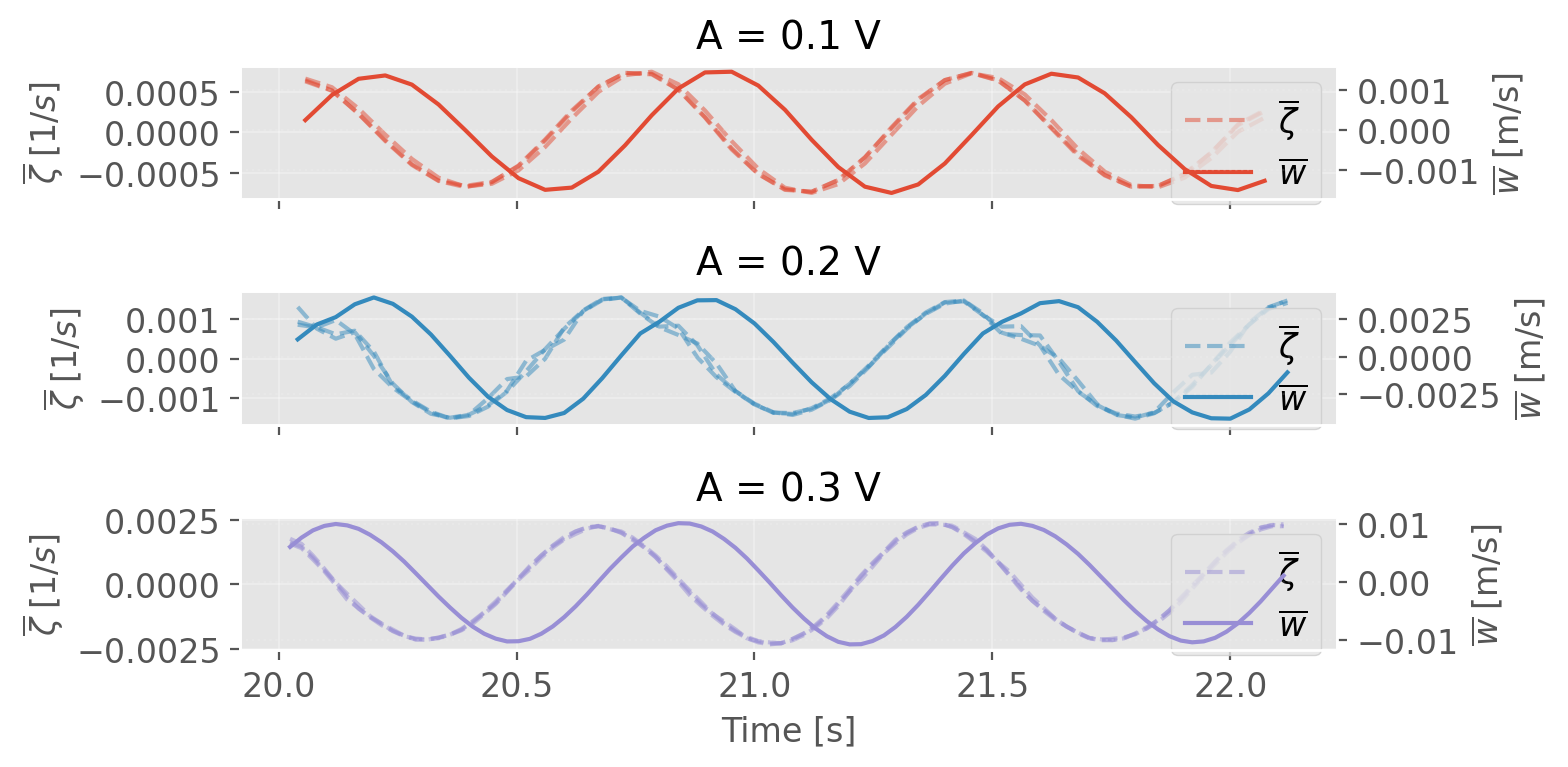

In [155]:
fig, ax = plt.subplots(3, 1, figsize=(8, 4), sharex=True)

# Mean vertical velocity over x and z for each time step
mean_w_a01 = np.mean([
    piv_a01_r1['w'].mean(axis=(1, 2)),
    piv_a01_r2['w'].mean(axis=(1, 2)),
    piv_a01_r3['w'].mean(axis=(1, 2))
], axis=0)

mean_w_a02 = np.mean([
    piv_a02_r1['w'].mean(axis=(1, 2)),
    piv_a02_r2['w'].mean(axis=(1, 2)),
    piv_a02_r3['w'].mean(axis=(1, 2))
], axis=0)
mean_w_a03 = np.mean([
    piv_a03_r1['w'].mean(axis=(1, 2)),
    piv_a03_r2['w'].mean(axis=(1, 2)),
    piv_a03_r3['w'].mean(axis=(1, 2))
], axis=0)


ax_w = [a.twinx() for a in ax]

ax[0].plot(piv_a01_r1.time, curl_a01_r1, color='C0', linestyle='--', alpha=0.5, label=r'$\overline{\zeta}$')
ax[0].plot(piv_a01_r2.time, curl_a01_r2, color='C0', linestyle='--', alpha=0.5)
ax[0].plot(piv_a01_r3.time, curl_a01_r3, color='C0', linestyle='--', alpha=0.5)
ax_w[0].plot(piv_a01_r1.time, mean_w_a01, color='C0', linestyle='-', label=r'$\overline{w}$')

ax[1].plot(piv_a02_r1.time, curl_a02_r1, color='C1', linestyle='--', alpha=0.5, label=r'$\overline{\zeta}$')
ax[1].plot(piv_a02_r2.time, curl_a02_r2, color='C1', linestyle='--', alpha=0.5)
ax[1].plot(piv_a02_r3.time, curl_a02_r3, color='C1', linestyle='--', alpha=0.5)
ax_w[1].plot(piv_a02_r1.time, mean_w_a02, color='C1', linestyle='-', label=r'$\overline{w}$')


ax[2].plot(piv_a03_r1.time, curl_a03_r1, color='C2', linestyle='--', alpha=0.5, label=r'$\overline{\zeta}$')
ax[2].plot(piv_a03_r2.time, curl_a03_r2, color='C2', linestyle='--', alpha=0.5)
ax[2].plot(piv_a03_r3.time, curl_a03_r3, color='C2', linestyle='--', alpha=0.5)
ax_w[2].plot(piv_a03_r1.time, mean_w_a03, color='C2', linestyle='-', label=r'$\overline{w}$')

for a, aw in zip(ax, ax_w):
    handles1, labels1 = a.get_legend_handles_labels()
    handles2, labels2 = aw.get_legend_handles_labels()
    a.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

# Labels
ax[0].set_ylabel(r'$\overline{\zeta} \; [1/s]$')
ax[1].set_ylabel(r'$\overline{\zeta} \; [1/s]$')
ax[2].set_ylabel(r'$\overline{\zeta} \; [1/s]$')

ax_w[0].set_ylabel(r'$\overline{w} \; [\mathrm{m/s}]$')
ax_w[1].set_ylabel(r'$\overline{w} \; [\mathrm{m/s}]$')
ax_w[2].set_ylabel(r'$\overline{w} \; [\mathrm{m/s}]$')

ax[0].set_title('A = 0.1 V')
ax[1].set_title('A = 0.2 V')
ax[2].set_title('A = 0.3 V')

for a in ax:
    # main, slightly stronger grid (e.g. for zeta)
    a.yaxis.grid(True, linestyle='-', alpha=0.3)
    a.xaxis.grid(True, linestyle='-', alpha=0.3)

for aw in ax_w:
    # secondary, very light grid (for w)
    aw.yaxis.grid(True, linestyle=':', alpha=0.15)
    aw.set_axisbelow(True)  # keep grid behind data

ax[2].set_xlabel('Time [s]')

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/mean_vorticity_vs_vertical_velocity.png", dpi=300)

### Divergence

In [156]:
def divergence_over_time(df):
    u = (-1) * df['u'].values
    w = df['w'].values

    dudx = np.gradient(u, axis=1)  # du/dx
    dwdz = np.gradient(w, axis=0)  # dw/dy

    divergence = dudx + dwdz

    divergence_mean = np.mean(divergence, axis=(1, 2))  # mean divergence over x and z for each time step

    return divergence_mean

In [157]:
div_a01_r1 = divergence_over_time(piv_a01_r1)
div_a01_r2 = divergence_over_time(piv_a01_r2)
div_a01_r3 = divergence_over_time(piv_a01_r3)

div_a02_r1 = divergence_over_time(piv_a02_r1)
div_a02_r2 = divergence_over_time(piv_a02_r2)
div_a02_r3 = divergence_over_time(piv_a02_r3)

div_a03_r1 = divergence_over_time(piv_a03_r1)
div_a03_r2 = divergence_over_time(piv_a03_r2)
div_a03_r3 = divergence_over_time(piv_a03_r3)

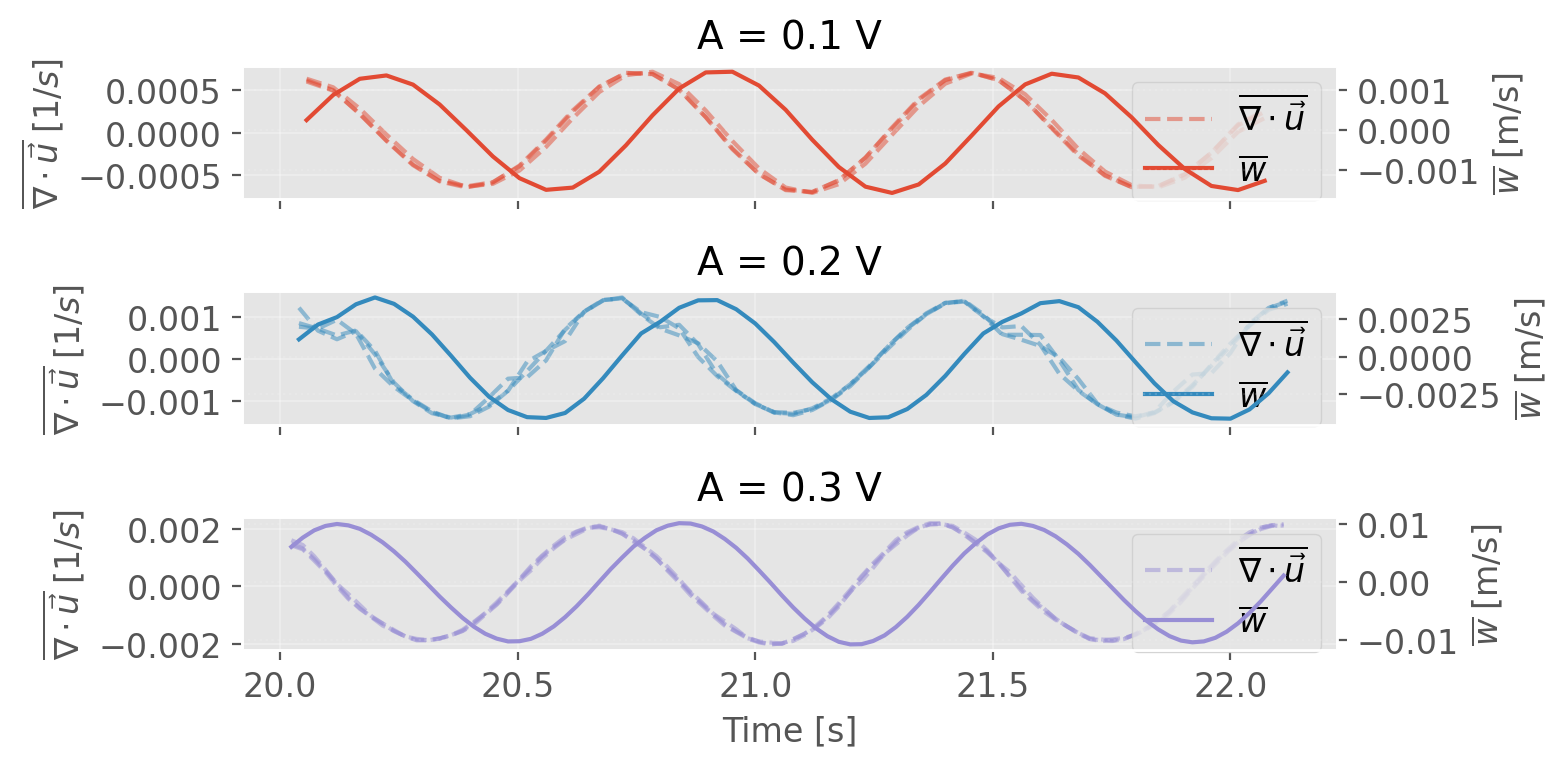

In [158]:
fig, ax = plt.subplots(3, 1, figsize=(8, 4), sharex=True)

# Mean vertical velocity over x and z for each time step
mean_w_a01 = np.mean([
    piv_a01_r1['w'].mean(axis=(1, 2)),
    piv_a01_r2['w'].mean(axis=(1, 2)),
    piv_a01_r3['w'].mean(axis=(1, 2))
], axis=0)

mean_w_a02 = np.mean([
    piv_a02_r1['w'].mean(axis=(1, 2)),
    piv_a02_r2['w'].mean(axis=(1, 2)),
    piv_a02_r3['w'].mean(axis=(1, 2))
], axis=0)
mean_w_a03 = np.mean([
    piv_a03_r1['w'].mean(axis=(1, 2)),
    piv_a03_r2['w'].mean(axis=(1, 2)),
    piv_a03_r3['w'].mean(axis=(1, 2))
], axis=0)


ax_w = [a.twinx() for a in ax]

ax[0].plot(piv_a01_r1.time, div_a01_r1, color='C0', linestyle='--', alpha=0.5, label=r'$\overline{\nabla \cdot \vec{u}}$')
ax[0].plot(piv_a01_r2.time, div_a01_r2, color='C0', linestyle='--', alpha=0.5)
ax[0].plot(piv_a01_r3.time, div_a01_r3, color='C0', linestyle='--', alpha=0.5)
ax_w[0].plot(piv_a01_r1.time, mean_w_a01, color='C0', linestyle='-', label=r'$\overline{w}$')

ax[1].plot(piv_a02_r1.time, div_a02_r1, color='C1', linestyle='--', alpha=0.5, label=r'$\overline{\nabla \cdot \vec{u}}$')
ax[1].plot(piv_a02_r2.time, div_a02_r2, color='C1', linestyle='--', alpha=0.5)
ax[1].plot(piv_a02_r3.time, div_a02_r3, color='C1', linestyle='--', alpha=0.5)
ax_w[1].plot(piv_a02_r1.time, mean_w_a02, color='C1', linestyle='-', label=r'$\overline{w}$')


ax[2].plot(piv_a03_r1.time, div_a03_r1, color='C2', linestyle='--', alpha=0.5, label=r'$\overline{\nabla \cdot \vec{u}}$')
ax[2].plot(piv_a03_r2.time, div_a03_r2, color='C2', linestyle='--', alpha=0.5)
ax[2].plot(piv_a03_r3.time, div_a03_r3, color='C2', linestyle='--', alpha=0.5)
ax_w[2].plot(piv_a03_r1.time, mean_w_a03, color='C2', linestyle='-', label=r'$\overline{w}$')

for a, aw in zip(ax, ax_w):
    handles1, labels1 = a.get_legend_handles_labels()
    handles2, labels2 = aw.get_legend_handles_labels()
    a.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

# Labels
ax[0].set_ylabel(r'$\overline{\nabla \cdot \vec{u}} \; [1/s]$')
ax[1].set_ylabel(r'$\overline{\nabla \cdot \vec{u}} \; [1/s]$')
ax[2].set_ylabel(r'$\overline{\nabla \cdot \vec{u}} \; [1/s]$')

ax_w[0].set_ylabel(r'$\overline{w} \; [\mathrm{m/s}]$')
ax_w[1].set_ylabel(r'$\overline{w} \; [\mathrm{m/s}]$')
ax_w[2].set_ylabel(r'$\overline{w} \; [\mathrm{m/s}]$')

ax[0].set_title('A = 0.1 V')
ax[1].set_title('A = 0.2 V')
ax[2].set_title('A = 0.3 V')

for a in ax:
    # main, slightly stronger grid (e.g. for zeta)
    a.yaxis.grid(True, linestyle='-', alpha=0.3)
    a.xaxis.grid(True, linestyle='-', alpha=0.3)

for aw in ax_w:
    # secondary, very light grid (for w)
    aw.yaxis.grid(True, linestyle=':', alpha=0.15)
    aw.set_axisbelow(True)  # keep grid behind data

ax[2].set_xlabel('Time [s]')

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/mean_divergence_vs_vertical_velocity.png", dpi=300)

### Phase

#### u(t) vs w(t)

In [178]:
# Mean horizontal velocity over x and z for each time step
u_a01_r1 = (-1) * piv_a01_r1['u'].mean(axis=(1, 2)).values
u_a01_r2 = (-1) * piv_a01_r2['u'].mean(axis=(1, 2)).values
u_a01_r3 = (-1) * piv_a01_r3['u'].mean(axis=(1, 2)).values
u_a02_r1 = (-1) * piv_a02_r1['u'].mean(axis=(1, 2)).values
u_a02_r2 = (-1) * piv_a02_r2['u'].mean(axis=(1, 2)).values
u_a02_r3 = (-1) * piv_a02_r3['u'].mean(axis=(1, 2)).values
u_a03_r1 = (-1) * piv_a03_r1['u'].mean(axis=(1, 2)).values
u_a03_r2 = (-1) * piv_a03_r2['u'].mean(axis=(1, 2)).values
u_a03_r3 = (-1) * piv_a03_r3['u'].mean(axis=(1, 2)).values

w_a01_r1 = piv_a01_r1['w'].mean(axis=(1, 2)).values
w_a01_r2 = piv_a01_r2['w'].mean(axis=(1, 2)).values
w_a01_r3 = piv_a01_r3['w'].mean(axis=(1, 2)).values
w_a02_r1 = piv_a02_r1['w'].mean(axis=(1, 2)).values
w_a02_r2 = piv_a02_r2['w'].mean(axis=(1, 2)).values
w_a02_r3 = piv_a02_r3['w'].mean(axis=(1, 2)).values
w_a03_r1 = piv_a03_r1['w'].mean(axis=(1, 2)).values
w_a03_r2 = piv_a03_r2['w'].mean(axis=(1, 2)).values
w_a03_r3 = piv_a03_r3['w'].mean(axis=(1, 2)).values

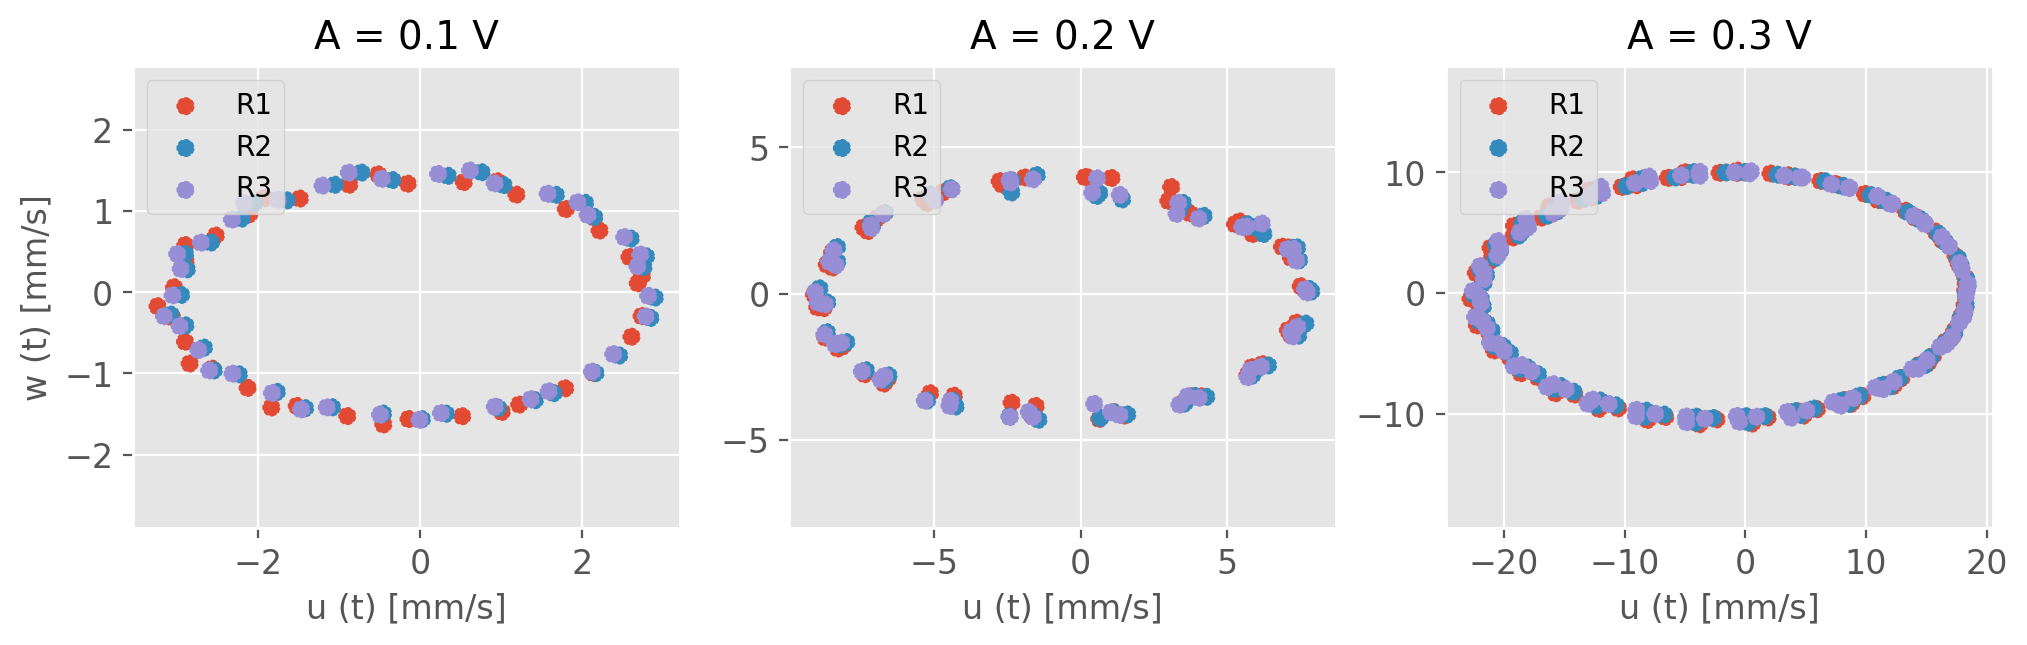

In [187]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

ax[0].set_title(f'A = 0.1 V')
ax[1].set_title(f'A = 0.2 V')
ax[2].set_title(f'A = 0.3 V')

ax[0].scatter(u_a01_r1*1000, w_a01_r1*1000, color='C0', linestyle='--', label='R1')
ax[0].scatter(u_a01_r2*1000, w_a01_r2*1000, color='C1', linestyle='--', label='R2')
ax[0].scatter(u_a01_r3*1000, w_a01_r3*1000, color='C2', linestyle='--', label='R3')

ax[1].scatter(u_a02_r1*1000, w_a02_r1*1000, color='C0', linestyle='--', label='R1')
ax[1].scatter(u_a02_r2*1000 , w_a02_r2*1000, color='C1', linestyle='--', label='R2')
ax[1].scatter(u_a02_r3*1000, w_a02_r3*1000, color='C2', linestyle='--', label='R3')

ax[2].scatter(u_a03_r1*1000, w_a03_r1*1000, color='C0', linestyle='--', label='R1')
ax[2].scatter(u_a03_r2*1000, w_a03_r2*1000, color='C1', linestyle='--', label='R2')
ax[2].scatter(u_a03_r3*1000, w_a03_r3*1000, color='C2', linestyle='--', label='R3')

for a in ax:
    a.set_xlabel('u (t) [mm/s]')
    a.axis('equal')
    a.legend(loc='upper left', fontsize=10)
ax[0].set_ylabel('w (t) [mm/s]')

plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/trajectory.png", dpi=300)

#### u(x) vs w(x)

In [161]:
u_a01_r1 = (-1) * piv_a01_r1['u'].mean(axis=(0, 1)).values
u_a01_r2 = (-1) * piv_a01_r2['u'].mean(axis=(0, 1)).values
u_a01_r3 = (-1) * piv_a01_r3['u'].mean(axis=(0, 1)).values
u_a02_r1 = (-1) * piv_a02_r1['u'].mean(axis=(0, 1)).values
u_a02_r2 = (-1) * piv_a02_r2['u'].mean(axis=(0, 1)).values
u_a02_r3 = (-1) * piv_a02_r3['u'].mean(axis=(0, 1)).values
u_a03_r1 = (-1) * piv_a03_r1['u'].mean(axis=(0, 1)).values
u_a03_r2 = (-1) * piv_a03_r2['u'].mean(axis=(0, 1)).values
u_a03_r3 = (-1) * piv_a03_r3['u'].mean(axis=(0, 1)).values

w_a01_r1 = piv_a01_r1['w'].mean(axis=(0, 1)).values
w_a01_r2 = piv_a01_r2['w'].mean(axis=(0, 1)).values
w_a01_r3 = piv_a01_r3['w'].mean(axis=(0, 1)).values
w_a02_r1 = piv_a02_r1['w'].mean(axis=(0, 1)).values
w_a02_r2 = piv_a02_r2['w'].mean(axis=(0, 1)).values
w_a02_r3 = piv_a02_r3['w'].mean(axis=(0, 1)).values
w_a03_r1 = piv_a03_r1['w'].mean(axis=(0, 1)).values
w_a03_r2 = piv_a03_r2['w'].mean(axis=(0, 1)).values
w_a03_r3 = piv_a03_r3['w'].mean(axis=(0, 1)).values

Text(0, 0.5, 'w (x) [m/s]')

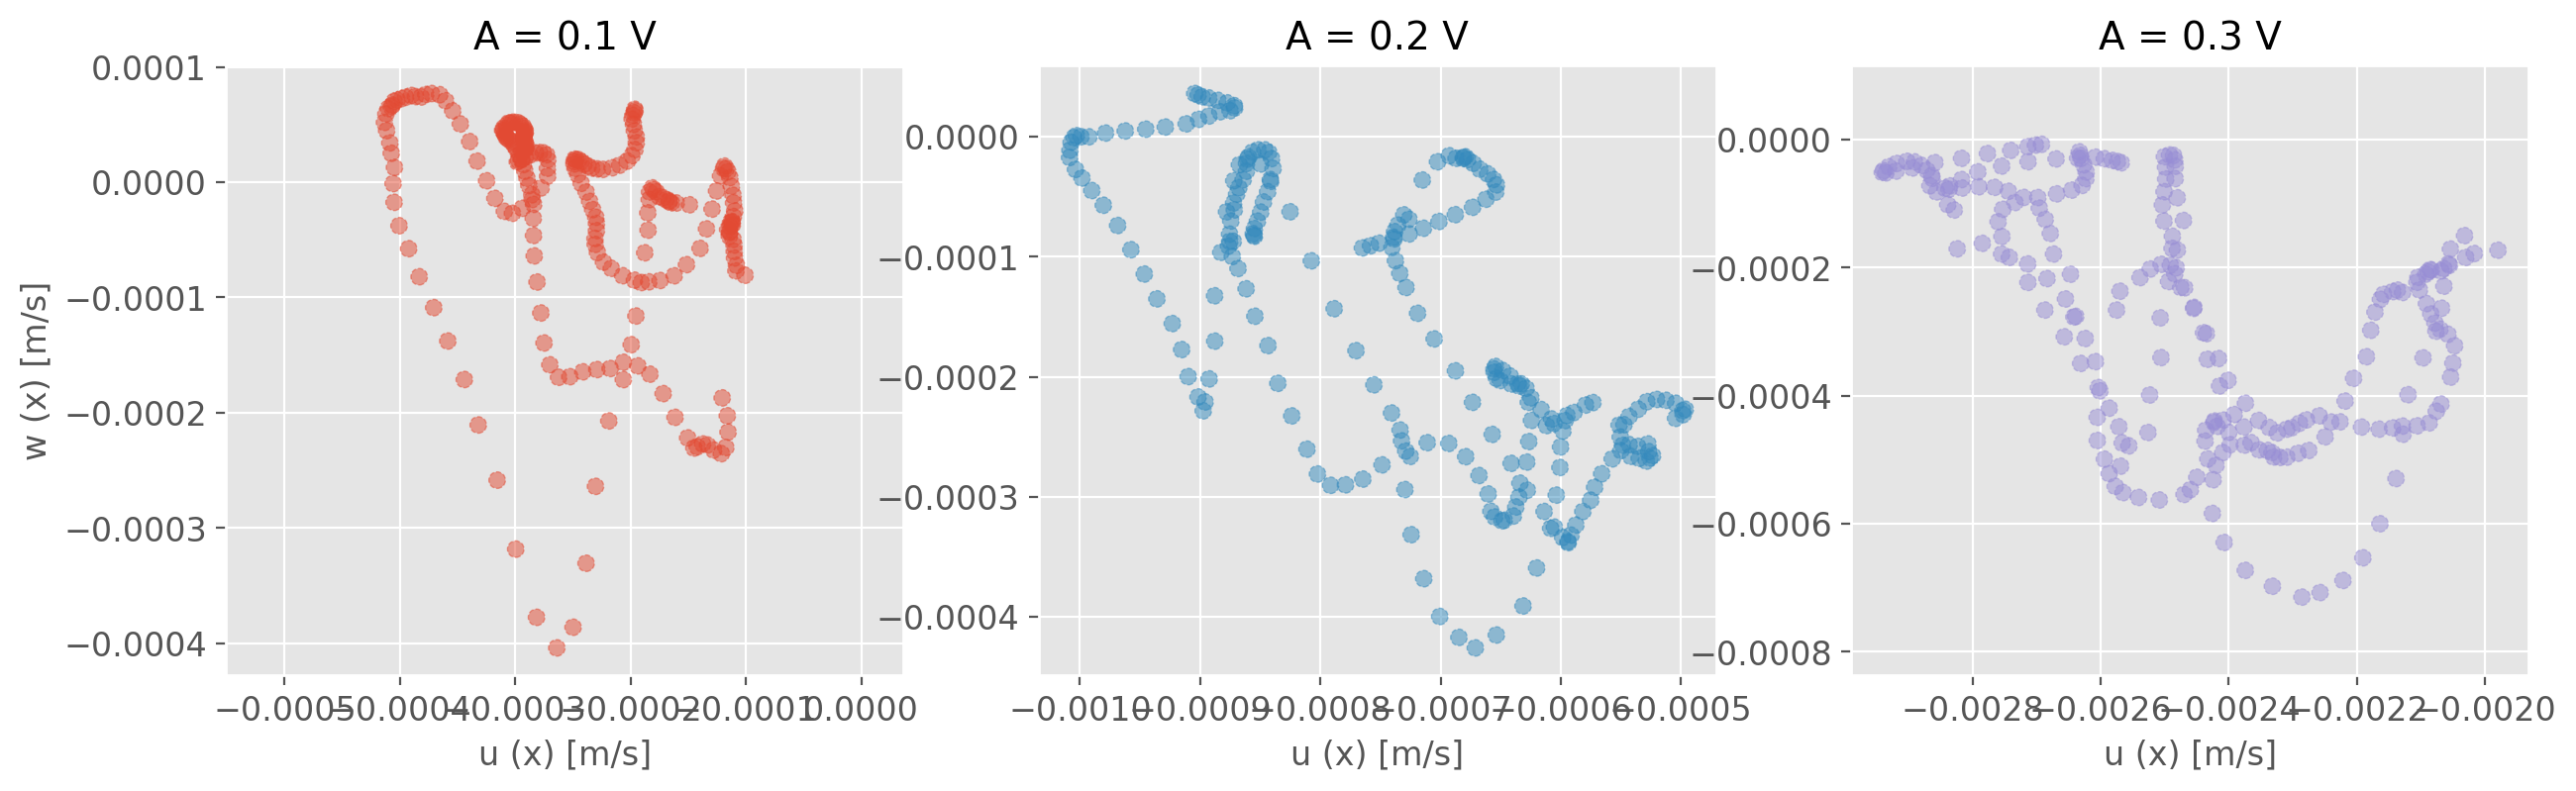

In [162]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].set_title(f'A = 0.1 V')
ax[1].set_title(f'A = 0.2 V')
ax[2].set_title(f'A = 0.3 V')

ax[0].scatter(u_a01_r1, w_a01_r1, color='C0', linestyle='--', alpha=0.5)
ax[0].scatter(u_a01_r2, w_a01_r2, color='C0', linestyle='--', alpha=0.5)
ax[0].scatter(u_a01_r3, w_a01_r3, color='C0', linestyle='--', alpha=0.5)

ax[1].scatter(u_a02_r1, w_a02_r1, color='C1', linestyle='--', alpha=0.5)
ax[1].scatter(u_a02_r2, w_a02_r2, color='C1', linestyle='--', alpha=0.5)
ax[1].scatter(u_a02_r3, w_a02_r3, color='C1', linestyle='--', alpha=0.5)

ax[2].scatter(u_a03_r1, w_a03_r1, color='C2', linestyle='--', alpha=0.5)
ax[2].scatter(u_a03_r2, w_a03_r2, color='C2', linestyle='--', alpha=0.5)
ax[2].scatter(u_a03_r3, w_a03_r3, color='C2', linestyle='--', alpha=0.5)

for a in ax:
    a.set_xlabel('u (x) [m/s]')
    a.axis('equal')
ax[0].set_ylabel('w (x) [m/s]')

#### u(z) vs w(z)

In [163]:
u_a01_r1 = (-1) * piv_a01_r1['u'].mean(axis=(0, 2)).values
u_a01_r2 = (-1) * piv_a01_r2['u'].mean(axis=(0, 2)).values
u_a01_r3 = (-1) * piv_a01_r3['u'].mean(axis=(0, 2)).values
u_a02_r1 = (-1) * piv_a02_r1['u'].mean(axis=(0, 2)).values
u_a02_r2 = (-1) * piv_a02_r2['u'].mean(axis=(0, 2)).values
u_a02_r3 = (-1) * piv_a02_r3['u'].mean(axis=(0, 2)).values
u_a03_r1 = (-1) * piv_a03_r1['u'].mean(axis=(0, 2)).values
u_a03_r2 = (-1) * piv_a03_r2['u'].mean(axis=(0, 2)).values
u_a03_r3 = (-1) * piv_a03_r3['u'].mean(axis=(0, 2)).values

w_a01_r1 = piv_a01_r1['w'].mean(axis=(0, 2)).values
w_a01_r2 = piv_a01_r2['w'].mean(axis=(0, 2)).values
w_a01_r3 = piv_a01_r3['w'].mean(axis=(0, 2)).values
w_a02_r1 = piv_a02_r1['w'].mean(axis=(0, 2)).values
w_a02_r2 = piv_a02_r2['w'].mean(axis=(0, 2)).values
w_a02_r3 = piv_a02_r3['w'].mean(axis=(0, 2)).values
w_a03_r1 = piv_a03_r1['w'].mean(axis=(0, 2)).values
w_a03_r2 = piv_a03_r2['w'].mean(axis=(0, 2)).values
w_a03_r3 = piv_a03_r3['w'].mean(axis=(0, 2)).values

Text(0, 0.5, 'w (z) [m/s]')

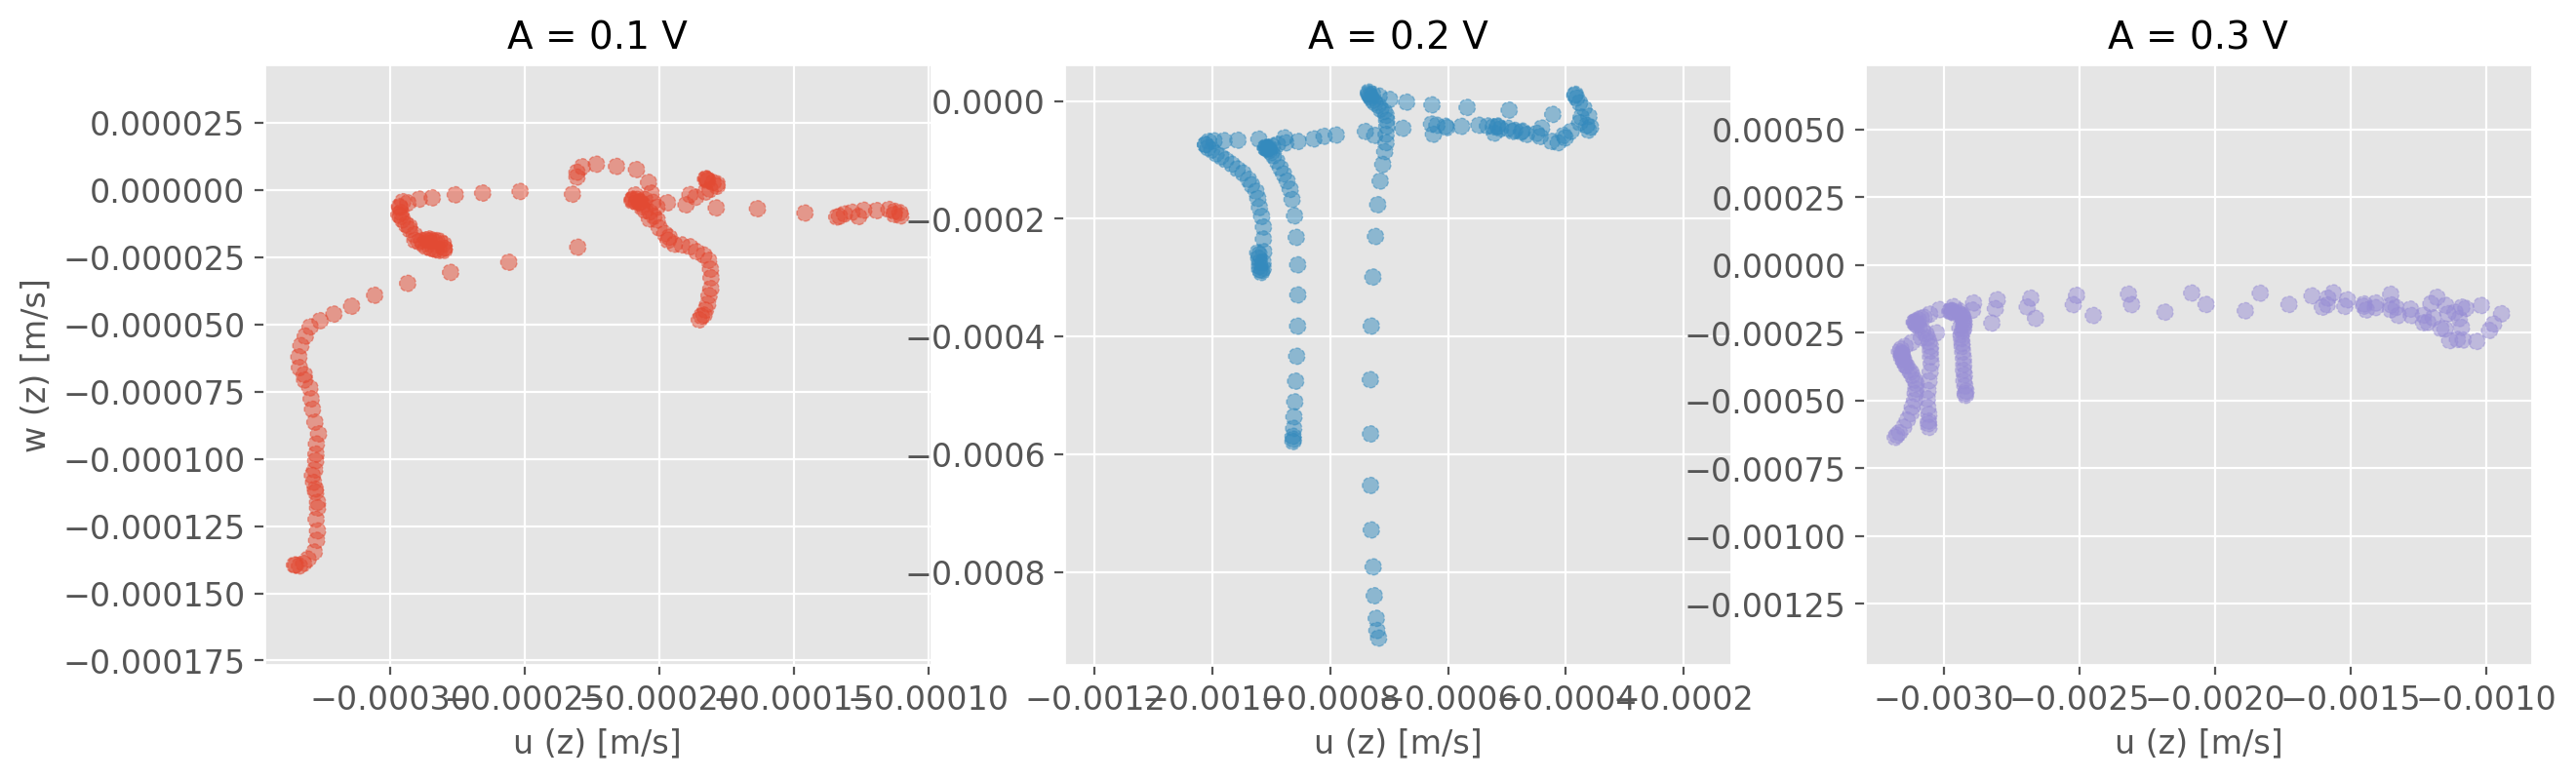

In [164]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].set_title(f'A = 0.1 V')
ax[1].set_title(f'A = 0.2 V')
ax[2].set_title(f'A = 0.3 V')

ax[0].scatter(u_a01_r1, w_a01_r1, color='C0', linestyle='--', alpha=0.5)
ax[0].scatter(u_a01_r2, w_a01_r2, color='C0', linestyle='--', alpha=0.5)
ax[0].scatter(u_a01_r3, w_a01_r3, color='C0', linestyle='--', alpha=0.5)

ax[1].scatter(u_a02_r1, w_a02_r1, color='C1', linestyle='--', alpha=0.5)
ax[1].scatter(u_a02_r2, w_a02_r2, color='C1', linestyle='--', alpha=0.5)
ax[1].scatter(u_a02_r3, w_a02_r3, color='C1', linestyle='--', alpha=0.5)

ax[2].scatter(u_a03_r1, w_a03_r1, color='C2', linestyle='--', alpha=0.5)
ax[2].scatter(u_a03_r2, w_a03_r2, color='C2', linestyle='--', alpha=0.5)
ax[2].scatter(u_a03_r3, w_a03_r3, color='C2', linestyle='--', alpha=0.5)

for a in ax:
    a.set_xlabel('u (z) [m/s]')
    a.axis('equal')
ax[0].set_ylabel('w (z) [m/s]')

In [165]:
trough = piv_a03_r1.time.values[13]
mid = piv_a03_r1.time.values[20]
crest = piv_a03_r1.time.values[27]

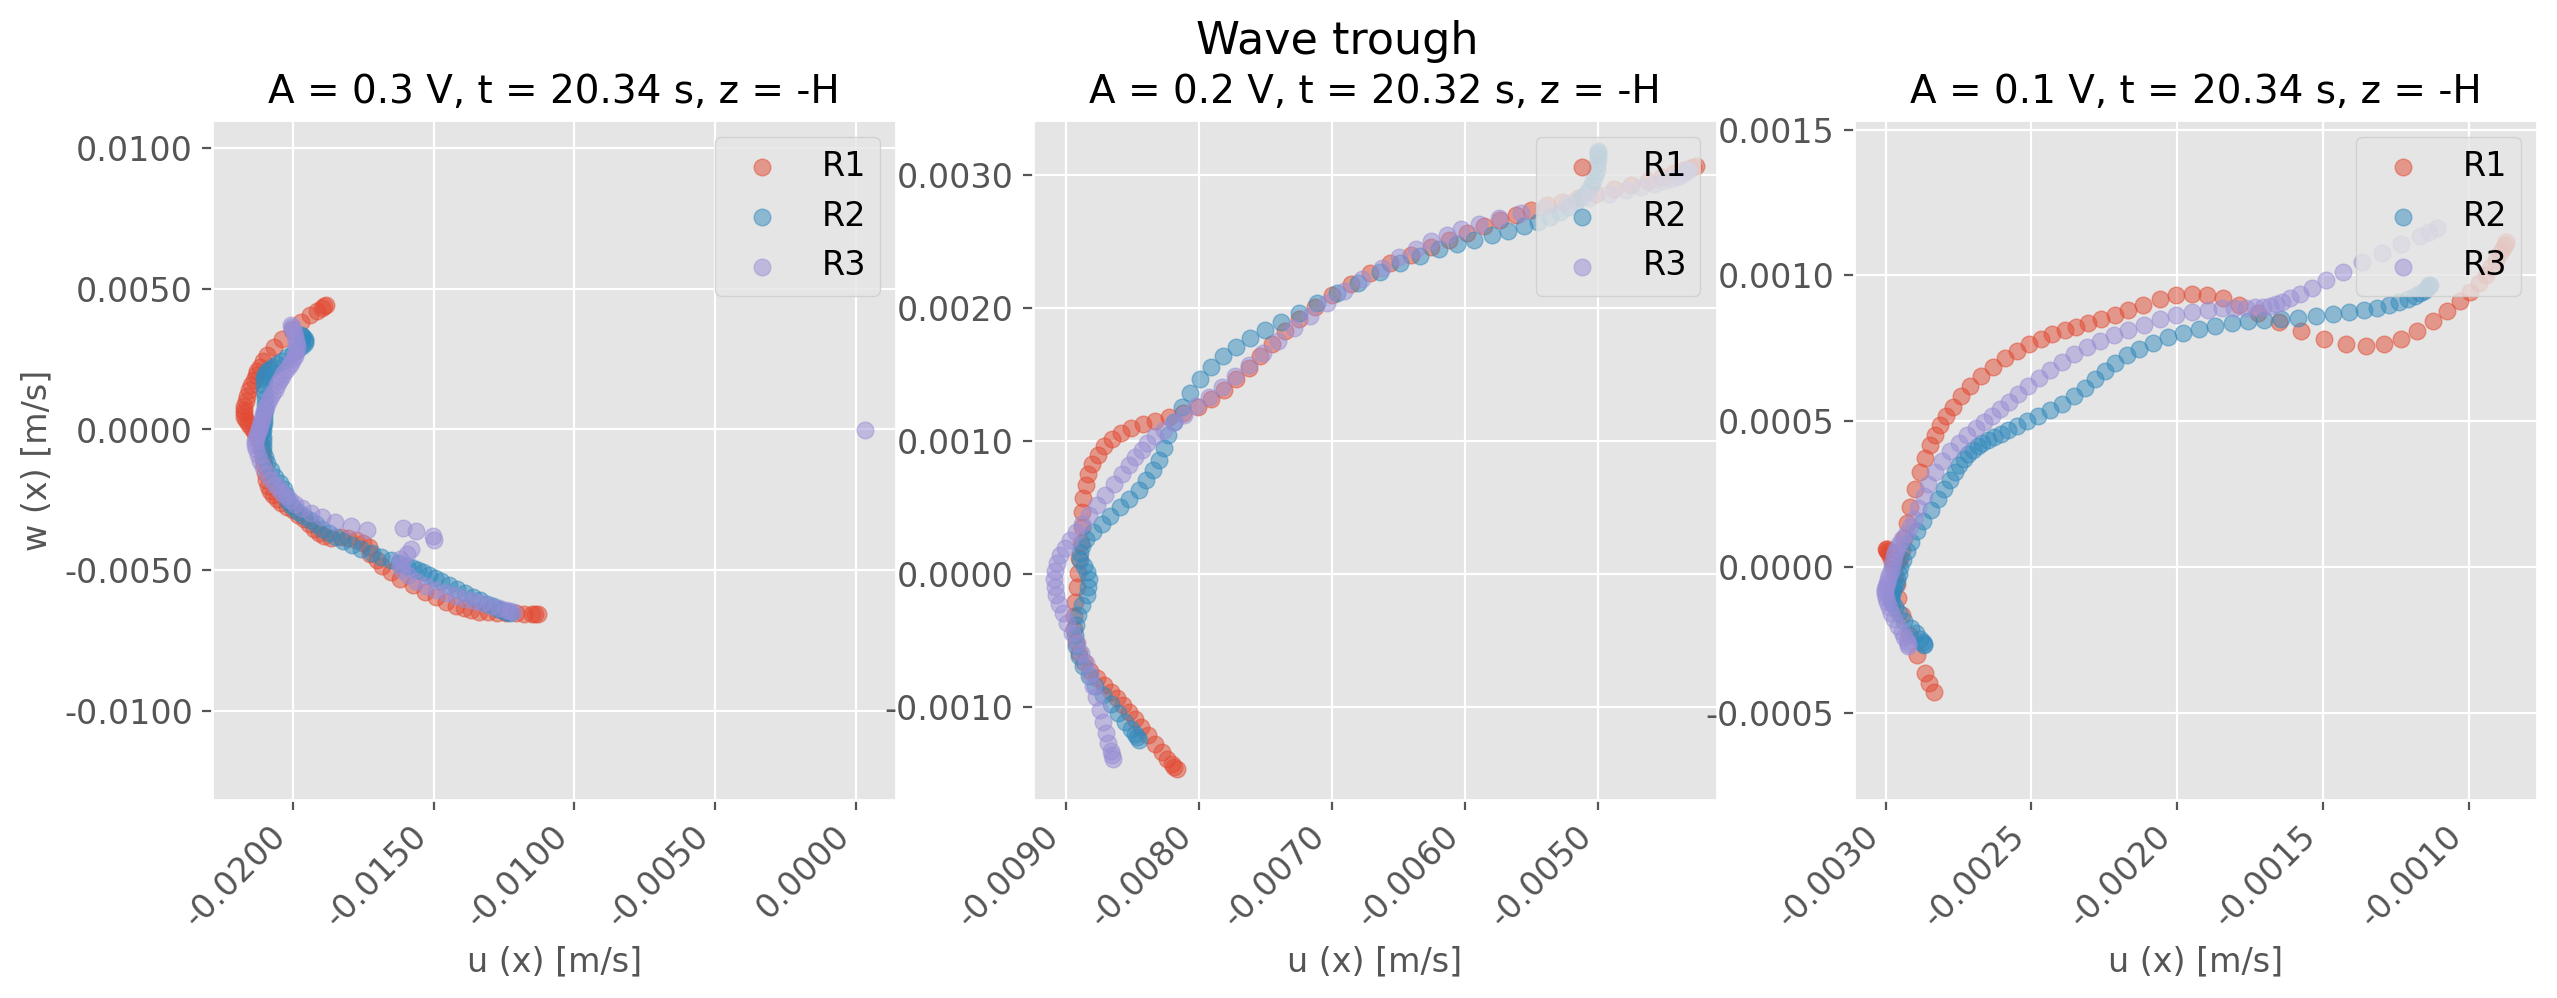

In [166]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title(f'A = 0.3 V, t = {piv_a03_r1.sel(time=trough, method="nearest").time.values:.2f} s, z = -H')
ax[1].set_title(f'A = 0.2 V, t = {piv_a02_r1.sel(time=trough, method="nearest").time.values:.2f} s, z = -H')
ax[2].set_title(f'A = 0.1 V, t = {piv_a01_r1.sel(time=trough, method="nearest").time.values:.2f} s, z = -H')

for j in range(42, 43):
    ax[0].scatter((-1)*piv_a03_r1['u'].isel(z=j).sel(time=trough, method='nearest'), 
                     piv_a03_r1['w'].isel(z=j).sel(time=trough, method='nearest' ), 
                     color='C0', alpha=0.5, label='R1')
    ax[0].scatter((-1)*piv_a03_r2['u'].isel(z=j).sel(time=trough, method='nearest'), 
                     piv_a03_r2['w'].isel(z=j).sel(time=trough, method='nearest' ), 
                     color='C1', alpha=0.5, label='R2')
    ax[0].scatter((-1)*piv_a03_r3['u'].isel(z=j).sel(time=trough, method='nearest'), 
                     piv_a03_r3['w'].isel(z=j).sel(time=trough, method='nearest' ), 
                     color='C2', alpha=0.5, label='R3')
    
    ax[1].scatter((-1)*piv_a02_r1['u'].isel(z=j).sel(time=trough, method='nearest'), 
                     piv_a02_r1['w'].isel(z=j).sel(time=trough, method='nearest' ), 
                     color='C0', alpha=0.5, label='R1')
    ax[1].scatter((-1)*piv_a02_r2['u'].isel(z=j).sel(time=trough, method='nearest'), 
                     piv_a02_r2['w'].isel(z=j).sel(time=trough, method='nearest' ), 
                     color='C1', alpha=0.5, label='R2')
    ax[1].scatter((-1)*piv_a02_r3['u'].isel(z=j).sel(time=trough, method='nearest'), 
                     piv_a02_r3['w'].isel(z=j).sel(time=trough, method='nearest' ), 
                     color='C2', alpha=0.5, label='R3')
    
    ax[2].scatter((-1)*piv_a01_r1['u'].isel(z=j).sel(time=trough, method='nearest'), 
                     piv_a01_r1['w'].isel(z=j).sel(time=trough, method='nearest' ), 
                     color='C0', alpha=0.5, label='R1')
    ax[2].scatter((-1)*piv_a01_r2['u'].isel(z=j).sel(time=trough, method='nearest'), 
                     piv_a01_r2['w'].isel(z=j).sel(time=trough, method='nearest' ), 
                     color='C1', alpha=0.5, label='R2')
    ax[2].scatter((-1)*piv_a01_r3['u'].isel(z=j).sel(time=trough, method='nearest'), 
                     piv_a01_r3['w'].isel(z=j).sel(time=trough, method='nearest' ), 
                     color='C2', alpha=0.5, label='R3')

for a in ax:
    a.set_xlabel('u (x) [m/s]')
    a.axis('equal')
    a.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    a.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    a.legend(loc='upper right')

ax[0].set_ylabel('w (x) [m/s]')
fig.autofmt_xdate(rotation=45)
fig.suptitle('Wave trough', fontsize=16)
plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/phase_plot_trough.png", dpi=300)

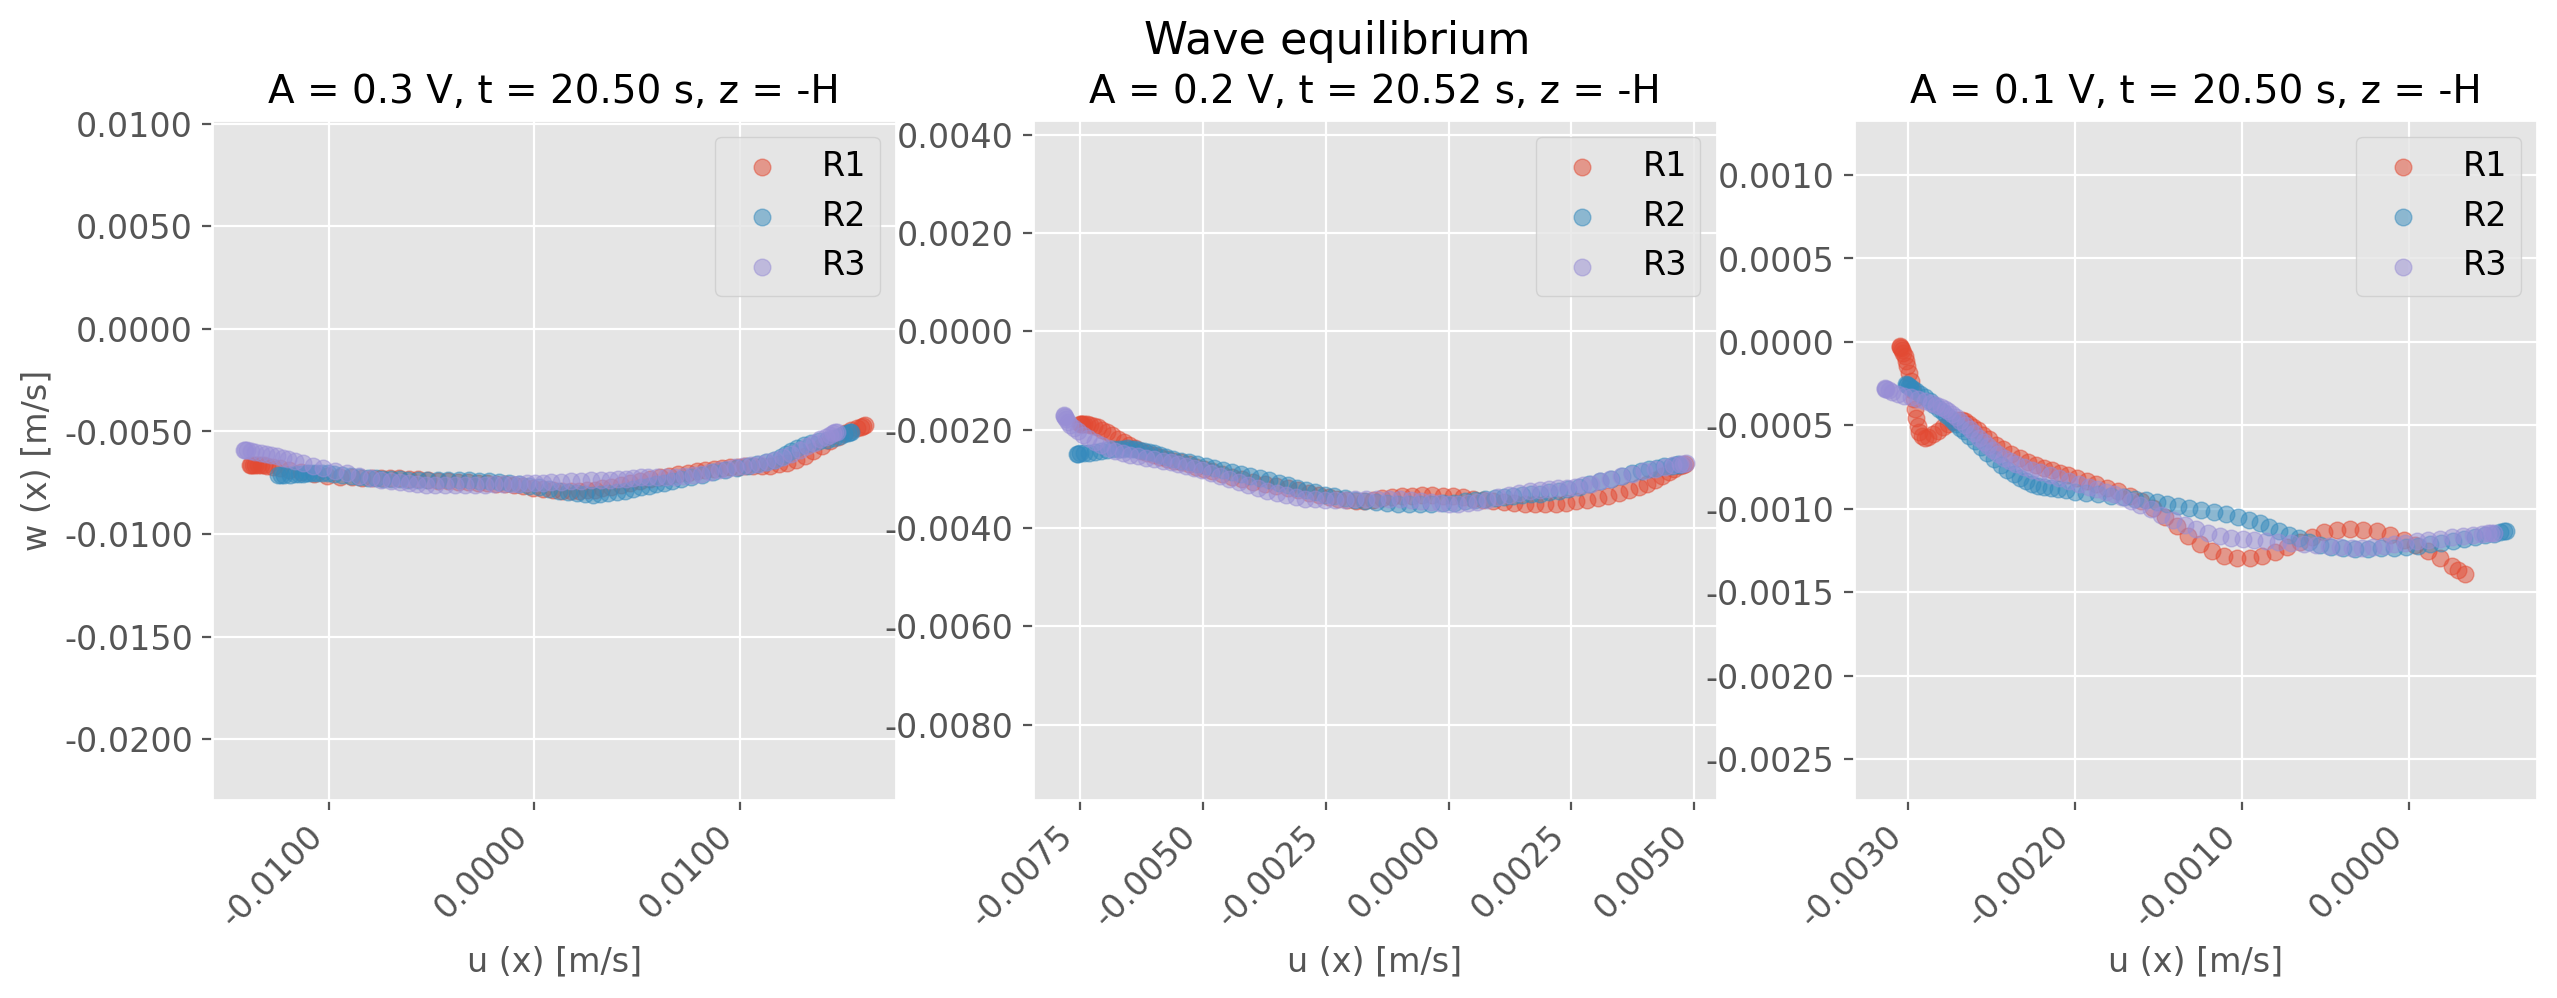

In [167]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title(f'A = 0.3 V, t = {piv_a03_r1.sel(time=mid, method="nearest").time.values:.2f} s, z = -H')
ax[1].set_title(f'A = 0.2 V, t = {piv_a02_r1.sel(time=mid, method="nearest").time.values:.2f} s, z = -H')
ax[2].set_title(f'A = 0.1 V, t = {piv_a01_r1.sel(time=mid, method="nearest").time.values:.2f} s, z = -H')

for j in range(42, 43):
    ax[0].scatter((-1)*piv_a03_r1['u'].isel(z=j).sel(time=mid, method='nearest'), 
                     piv_a03_r1['w'].isel(z=j).sel(time=mid, method='nearest' ), 
                     color='C0', alpha=0.5, label='R1')
    ax[0].scatter((-1)*piv_a03_r2['u'].isel(z=j).sel(time=mid, method='nearest'), 
                     piv_a03_r2['w'].isel(z=j).sel(time=mid, method='nearest' ), 
                     color='C1', alpha=0.5, label='R2')
    ax[0].scatter((-1)*piv_a03_r3['u'].isel(z=j).sel(time=mid, method='nearest'), 
                     piv_a03_r3['w'].isel(z=j).sel(time=mid, method='nearest' ), 
                     color='C2', alpha=0.5, label='R3')
    
    ax[1].scatter((-1)*piv_a02_r1['u'].isel(z=j).sel(time=mid, method='nearest'), 
                     piv_a02_r1['w'].isel(z=j).sel(time=mid, method='nearest' ), 
                     color='C0', alpha=0.5, label='R1')
    ax[1].scatter((-1)*piv_a02_r2['u'].isel(z=j).sel(time=mid, method='nearest'), 
                     piv_a02_r2['w'].isel(z=j).sel(time=mid, method='nearest' ), 
                     color='C1', alpha=0.5, label='R2')
    ax[1].scatter((-1)*piv_a02_r3['u'].isel(z=j).sel(time=mid, method='nearest'), 
                     piv_a02_r3['w'].isel(z=j).sel(time=mid, method='nearest' ), 
                     color='C2', alpha=0.5, label='R3')
    
    ax[2].scatter((-1)*piv_a01_r1['u'].isel(z=j).sel(time=mid, method='nearest'), 
                     piv_a01_r1['w'].isel(z=j).sel(time=mid, method='nearest' ), 
                     color='C0', alpha=0.5, label='R1')
    ax[2].scatter((-1)*piv_a01_r2['u'].isel(z=j).sel(time=mid, method='nearest'), 
                     piv_a01_r2['w'].isel(z=j).sel(time=mid, method='nearest' ), 
                     color='C1', alpha=0.5, label='R2')
    ax[2].scatter((-1)*piv_a01_r3['u'].isel(z=j).sel(time=mid, method='nearest'), 
                     piv_a01_r3['w'].isel(z=j).sel(time=mid, method='nearest' ), 
                     color='C2', alpha=0.5, label='R3')

for a in ax:
    a.set_xlabel('u (x) [m/s]')
    a.axis('equal')
    a.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    a.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    a.legend(loc='upper right')

ax[0].set_ylabel('w (x) [m/s]')
fig.autofmt_xdate(rotation=45)
fig.suptitle('Wave equilibrium', fontsize=16)
plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/phase_plot_mid.png", dpi=300)

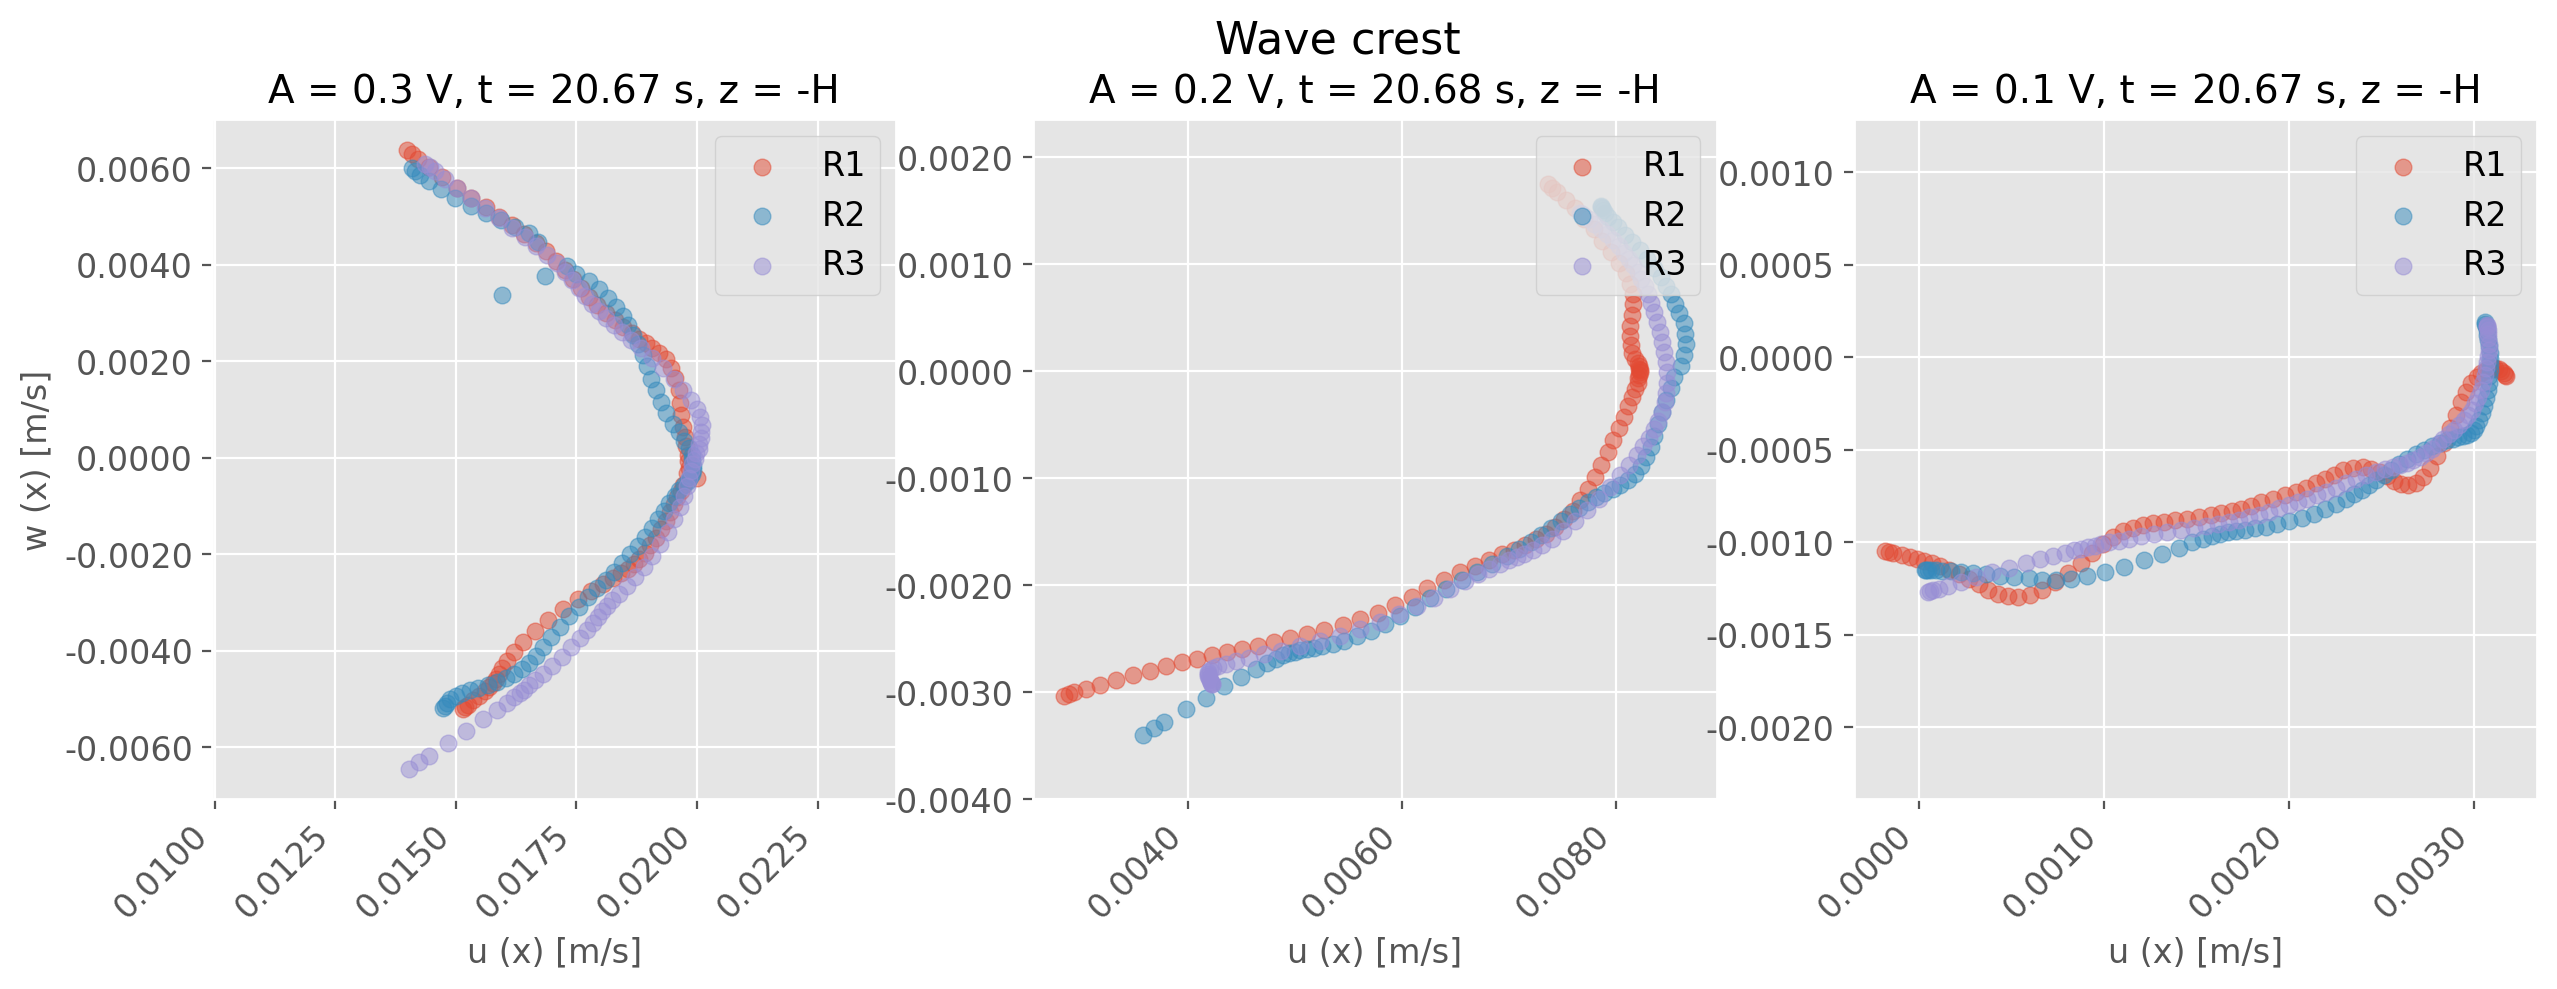

In [168]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title(f'A = 0.3 V, t = {piv_a03_r1.sel(time=crest, method="nearest").time.values:.2f} s, z = -H')
ax[1].set_title(f'A = 0.2 V, t = {piv_a02_r1.sel(time=crest, method="nearest").time.values:.2f} s, z = -H')
ax[2].set_title(f'A = 0.1 V, t = {piv_a01_r1.sel(time=crest, method="nearest").time.values:.2f} s, z = -H')

for j in range(42, 43):
    ax[0].scatter((-1)*piv_a03_r1['u'].isel(z=j).sel(time=crest, method='nearest'), 
                     piv_a03_r1['w'].isel(z=j).sel(time=crest, method='nearest' ), 
                     color='C0', alpha=0.5, label='R1')
    ax[0].scatter((-1)*piv_a03_r2['u'].isel(z=j).sel(time=crest, method='nearest'), 
                     piv_a03_r2['w'].isel(z=j).sel(time=crest, method='nearest' ), 
                     color='C1', alpha=0.5, label='R2')
    ax[0].scatter((-1)*piv_a03_r3['u'].isel(z=j).sel(time=crest, method='nearest'), 
                     piv_a03_r3['w'].isel(z=j).sel(time=crest, method='nearest' ), 
                     color='C2', alpha=0.5, label='R3')
    
    ax[1].scatter((-1)*piv_a02_r1['u'].isel(z=j).sel(time=crest, method='nearest'), 
                     piv_a02_r1['w'].isel(z=j).sel(time=crest, method='nearest' ), 
                     color='C0', alpha=0.5, label='R1')
    ax[1].scatter((-1)*piv_a02_r2['u'].isel(z=j).sel(time=crest, method='nearest'), 
                     piv_a02_r2['w'].isel(z=j).sel(time=crest, method='nearest' ), 
                     color='C1', alpha=0.5, label='R2')
    ax[1].scatter((-1)*piv_a02_r3['u'].isel(z=j).sel(time=crest, method='nearest'), 
                     piv_a02_r3['w'].isel(z=j).sel(time=crest, method='nearest' ), 
                     color='C2', alpha=0.5, label='R3')
    
    ax[2].scatter((-1)*piv_a01_r1['u'].isel(z=j).sel(time=crest, method='nearest'), 
                     piv_a01_r1['w'].isel(z=j).sel(time=crest, method='nearest' ), 
                     color='C0', alpha=0.5, label='R1')
    ax[2].scatter((-1)*piv_a01_r2['u'].isel(z=j).sel(time=crest, method='nearest'), 
                     piv_a01_r2['w'].isel(z=j).sel(time=crest, method='nearest' ), 
                     color='C1', alpha=0.5, label='R2')
    ax[2].scatter((-1)*piv_a01_r3['u'].isel(z=j).sel(time=crest, method='nearest'), 
                     piv_a01_r3['w'].isel(z=j).sel(time=crest, method='nearest' ), 
                     color='C2', alpha=0.5, label='R3')

for a in ax:
    a.set_xlabel('u (x) [m/s]')
    a.axis('equal')
    a.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    a.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    a.legend(loc='upper right')

ax[0].set_ylabel('w (x) [m/s]')
fig.autofmt_xdate(rotation=45)
fig.suptitle('Wave crest', fontsize=16)
plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/phase_plot_crest.png", dpi=300)

In [169]:
t_idx = 27

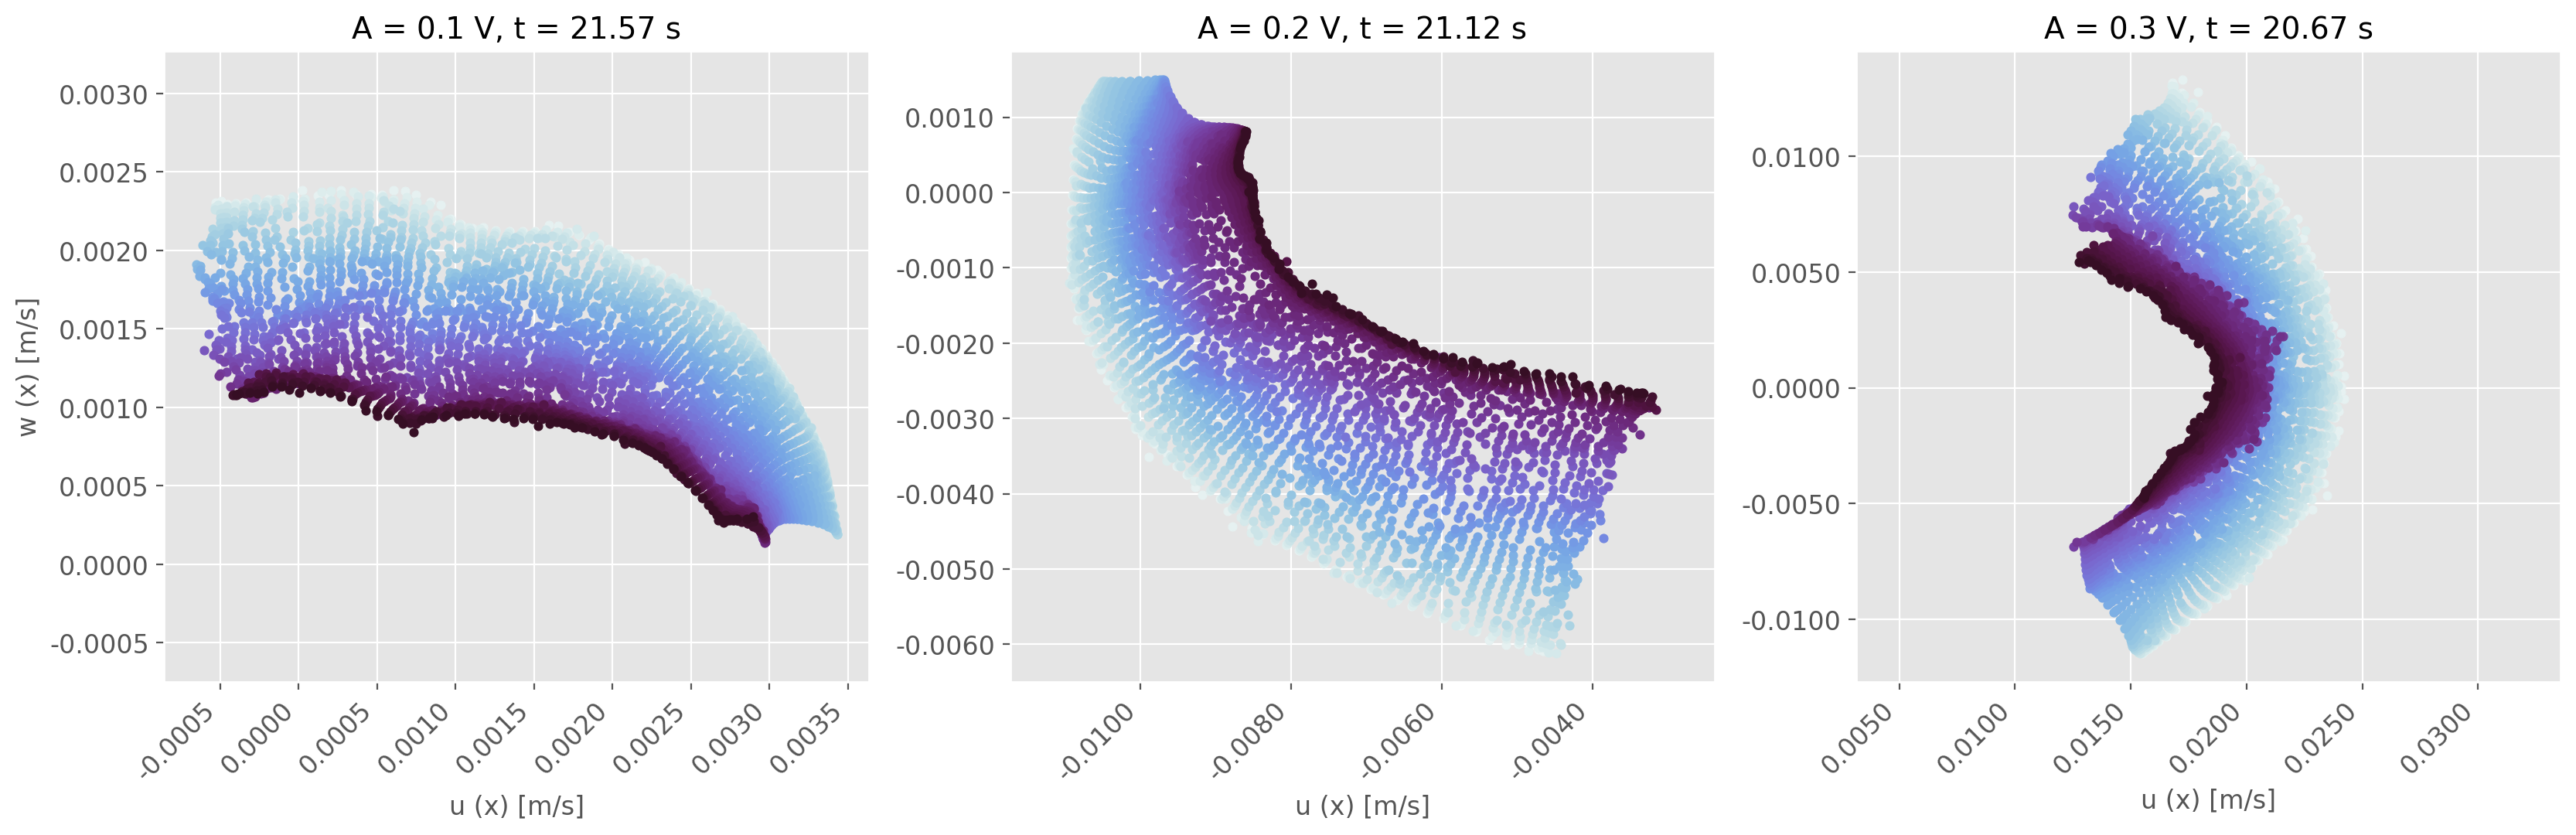

In [170]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].set_title(f'A = 0.1 V, t = {piv_a01_r1.time.values[t_idx]:.2f} s')
ax[1].set_title(f'A = 0.2 V, t = {piv_a02_r1.time.values[t_idx]:.2f} s')
ax[2].set_title(f'A = 0.3 V, t = {piv_a03_r1.time.values[t_idx]:.2f} s')

cmap = cmo.dense
colors = [cmap(i) for i in np.linspace(0, 1, 50)]

for j in range(50):
    color = colors[j]
    # Mean u and w across the 3 runs for each amplitude
    u_a01_mean = np.mean([piv_a01_r1['u'][t_idx, j, :], piv_a01_r2['u'][t_idx, j, :], piv_a01_r3['u'][t_idx, j, :]], axis=0)
    w_a01_mean = np.mean([piv_a01_r1['w'][t_idx, j, :], piv_a01_r2['w'][t_idx, j, :], piv_a01_r3['w'][t_idx, j, :]], axis=0)

    u_a02_mean = np.mean([piv_a02_r1['u'][t_idx, j, :], piv_a02_r2['u'][t_idx, j, :], piv_a02_r3['u'][t_idx, j, :]], axis=0)
    w_a02_mean = np.mean([piv_a02_r1['w'][t_idx, j, :], piv_a02_r2['w'][t_idx, j, :], piv_a02_r3['w'][t_idx, j, :]], axis=0)

    u_a03_mean = np.mean([piv_a03_r1['u'][t_idx, j, :], piv_a03_r2['u'][t_idx, j, :], piv_a03_r3['u'][t_idx, j, :]], axis=0)
    w_a03_mean = np.mean([piv_a03_r1['w'][t_idx, j, :], piv_a03_r2['w'][t_idx, j, :], piv_a03_r3['w'][t_idx, j, :]], axis=0)

    ax[0].scatter((-1)*u_a01_mean, w_a01_mean, s=15, color=color)
    ax[1].scatter((-1)*u_a02_mean, w_a02_mean, s=15, color=color)
    ax[2].scatter((-1)*u_a03_mean, w_a03_mean, s=15, color=color)

for a in ax:
    a.set_xlabel('u (x) [m/s]')
    a.axis('equal')
    a.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    a.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

fig.autofmt_xdate(rotation=45)
ax[0].set_ylabel('w (x) [m/s]')

plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/velocity_scatter_{t_idx}.png", dpi=300)

### Example on non linear effects

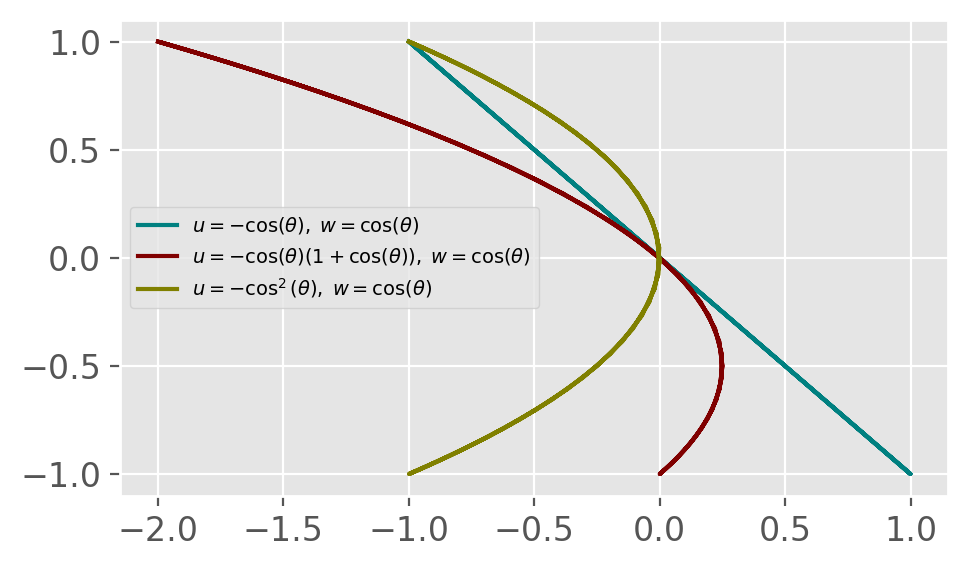

In [171]:
theta = np.linspace(-2*np.pi, 2*np.pi, 100)

u1 = -np.cos(theta)
w1 = np.cos(theta)

u2 = -np.cos(theta)*(1 + np.cos(theta))
u3 = -np.cos(theta)**2

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(u1, w1, color='teal', label=r'$u = -\cos(\theta), \; w = \cos(\theta)$')
ax.plot(u2, w1, color='maroon', label=r'$u = -\cos(\theta)(1 + \cos(\theta)), \; w = \cos(\theta)$')
ax.plot(u3, w1, color='olive', label=r'$u = -\cos^2(\theta), \; w = \cos(\theta)$')

ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/phase_plot_nonlinear.png", dpi=300)

# Sensitivity of theoretical w

In [172]:
# Baseline parameters for theory vs. observation comparison
A0 = A03                      
D0 = 0.20                     
H0 = 0.15                     
f0 = 1.4                      
h0 = 0.010             
x0 = 8.06 - 4.86        
t  = time_piv                

# Compute baseline wavenumber & damping from your models
k0 = wave_number_in_theory(f0, H0)
a0, _ = spatial_damping_coefficient(k0, D0, H0, h0)

# Compute theoretical vertical velocity at the observation point (x0, z=-H0) over time
W0 = vertical_velocity(A0, D0, H0, f0, a0, k0, h0, x0, t)

In [173]:
k_factors = np.linspace(0.5, 1.5, 51)   # -90% to +90%
W_k = []

# W for variations in k, keeping other parameters fixed at their baseline values
for fac in k_factors:
    k = fac * k0
    a, a_err = spatial_damping_coefficient(k, D0, H0, h0)
    W_k.append(vertical_velocity(A0, D0, H0, f0, a, k, h0, x0, t))

W_k = np.array(W_k)

D_factors = np.linspace(0.5, 1.5, 51)
W_D = []

# W for variations in D, keeping other parameters fixed at their baseline values
for fac in D_factors:
    k = estimate_wavenumber(f0, fac * D0)
    a, _ = spatial_damping_coefficient(k0, fac * D0, H0, h0)
    W_D.append(vertical_velocity(A0, fac * D0, H0, f0, a, k0, h0, x0, t))

W_D = np.array(W_D)

h_factors = np.linspace(0.5, 1.5, 51)
W_h = []

# W for variations in h, keeping other parameters fixed at their baseline values
for fac in h_factors:
    a, _ = spatial_damping_coefficient(k0, D0, H0, fac * h0)
    W_h.append(vertical_velocity(A0, D0, H0, f0, a, k0, fac * h0, x0, t))

W_h = np.array(W_h)

A_factors = np.linspace(0.5, 1.5, 51)
W_A = []

# W for variations in A, keeping other parameters fixed at their baseline values
for fac in A_factors:
    a, _ = spatial_damping_coefficient(k0, D0, H0, h0)
    W_A.append(vertical_velocity(fac * A0, D0, H0, f0, a, k0, h0, x0, t))

W_A = np.array(W_A)

H_factors = np.linspace(0.5, 1.5, 51)
W_H = []

# W for variations in H, keeping other parameters fixed at their baseline values
for fac in H_factors:
    a, _ = spatial_damping_coefficient(k0, D0, fac * H0, h0)
    W_H.append(vertical_velocity(A0, D0, fac * H0, f0, a, k0, h0, x0, t))

W_H = np.array(W_H)

In [174]:
def rms(obs, theory):
    return np.sqrt(np.mean((obs - theory) ** 2))

In [175]:
W_k_rms = [rms(W0, W_k[i]) for i in range(len(k_factors))]
W_D_rms = [rms(W0, W_D[i]) for i in range(len(D_factors))]
W_h_rms = [rms(W0, W_h[i]) for i in range(len(h_factors))]
W_A_rms = [rms(W0, W_A[i]) for i in range(len(A_factors))]
W_H_rms = [rms(W0, W_H[i]) for i in range(len(H_factors))]

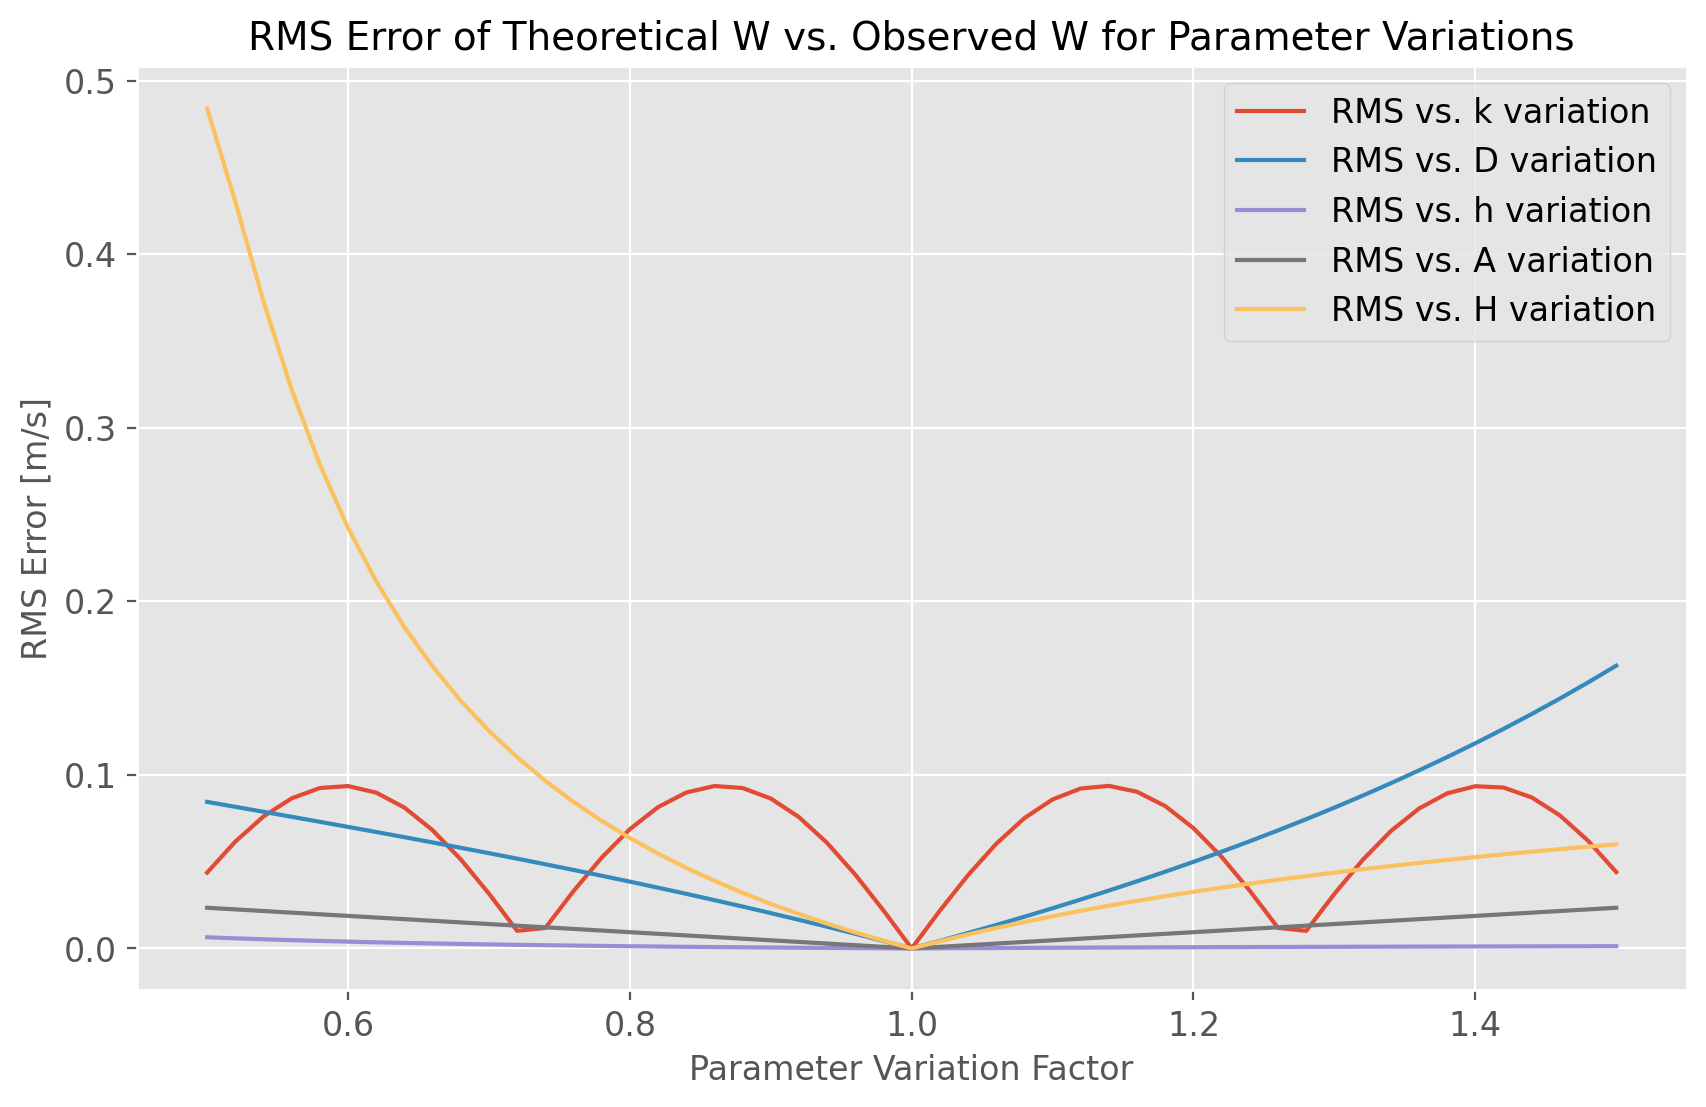

In [176]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_factors, W_k_rms, label='RMS vs. k variation', color='C0')
ax.plot(D_factors, W_D_rms, label='RMS vs. D variation', color='C1')
ax.plot(h_factors, W_h_rms, label='RMS vs. h variation', color='C2')
ax.plot(A_factors, W_A_rms, label='RMS vs. A variation', color='C3')
ax.plot(H_factors, W_H_rms, label='RMS vs. H variation', color='C4')
ax.set_xlabel('Parameter Variation Factor')
ax.set_ylabel('RMS Error [m/s]')
ax.set_title('RMS Error of Theoretical W vs. Observed W for Parameter Variations')
ax.legend()